**Chapter 10 – Introduction to Artificial Neural Networks with Keras**

# Setup

This project requires Python 3.7 or above:

In [4]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [6]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

And TensorFlow ≥ 2.8:

In [8]:
import tensorflow as tf
import numpy as np
# Desactiva la notación científica
np.set_printoptions(suppress=True)

assert version.parse(tf.__version__) >= version.parse("2.8.0")

Como hicimos en capítulos anteriores, definamos los tamaños de fuente predeterminados para que las figuras se vean más bonitas:

In [10]:
import matplotlib.pyplot as plt  # Importa la librería matplotlib para crear gráficos

# Configura el tamaño de fuente general por defecto en los gráficos
plt.rc('font', size=14)

# Configura el tamaño de las etiquetas de los ejes (x, y) y el tamaño del título del gráfico
plt.rc('axes', labelsize=14, titlesize=14)

# Configura el tamaño de la fuente de la leyenda del gráfico
plt.rc('legend', fontsize=14)

# Configura el tamaño de las etiquetas en el eje x (números o categorías)
plt.rc('xtick', labelsize=10)

# Configura el tamaño de las etiquetas en el eje y (números o categorías)
plt.rc('ytick', labelsize=10)

Y vamos a crear la carpeta `images/ann` (si aún no existe) y definir la función `save_fig()` que se utiliza en este cuaderno para guardar las figuras en alta resolución para el libro:

In [12]:
from pathlib import Path  # Importa la clase Path para manejar rutas de archivos y carpetas de forma segura

# Crea la ruta donde se guardarán las imágenes: ./images/ann
IMAGES_PATH = Path() / "images" / "ann"

# Crea la carpeta si no existe
# parents=True permite crear también carpetas intermedias
# exist_ok=True evita error si la carpeta ya existe
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

# Función para guardar figuras generadas con matplotlib
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):

    # Construye la ruta completa del archivo usando el nombre de la figura
    # Ejemplo: images/ann/grafica1.png
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"

    # Ajusta automáticamente los espacios del gráfico para evitar que se encimen etiquetas o títulos
    if tight_layout:
        plt.tight_layout()

    # Guarda la figura en la ruta especificada
    # format = tipo de archivo (png, jpg, pdf, etc.)
    # dpi = resolución de la imagen (300 es calidad alta para artículos o reportes)
    plt.savefig(path, format=fig_extension, dpi=resolution)

# De las neuronas biológicas a las artificiales
## El perceptrón

In [14]:
import numpy as np  # Importa NumPy para manejar arreglos y cálculos numéricos
from sklearn.datasets import load_iris  # Función para cargar el dataset Iris
from sklearn.linear_model import Perceptron  # Implementación del modelo Perceptron en scikit-learn

# Carga el dataset Iris como DataFrame
iris = load_iris(as_frame=True)
iris.data.head(6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4


Selecciona solo dos características del dataset: longitud del pétalo (petal length (cm)) y ancho del pétalo (petal width (cm)) values convierte el DataFrame a un arreglo de NumPy

In [16]:
# .values convierte el DataFrame a un arreglo de NumPy
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
X[:6]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4]])

Variable Objetivo

In [18]:
iris.target.unique() #Los valores únicos

array([0, 1, 2])

In [19]:
iris.target[:5] #Los primeros 5 elementos

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [20]:
iris.target[-5:] #Los últimos 5 elementos

145    2
146    2
147    2
148    2
149    2
Name: target, dtype: int32

Crea la variable objetivo (target):
- <code> True </code> si la flor es Iris setosa.
- <code> False </code>  si es otra especie

In [22]:
y = (iris.target == 0)  # Iris setosa

In [23]:
y[:5] #Los primeros 5 elementos (como son 0, entonces devuelve True)

0    True
1    True
2    True
3    True
4    True
Name: target, dtype: bool

In [24]:
y[-5:] #Los últimos 5 elementos (Como son diferente de 0, entonces devuelve False) 

145    False
146    False
147    False
148    False
149    False
Name: target, dtype: bool

Crea el modelo de Perceptron.
random_state fija la semilla para que el entrenamiento sea reproducible

In [26]:
per_clf = Perceptron(random_state=42)
per_clf 

Perceptron(random_state=42)

 Entrena el modelo con los datos de entrada $X$ y las etiquetas $y$

In [28]:
per_clf.fit(X, y)

Perceptron(random_state=42)

Nuevos datos de flores para hacer predicción cada fila representa una flor con:

[longitud del pétalo, ancho del pétalo]

In [30]:
X_new = [[2, 0.5], [3, 1]]
X_new

[[2, 0.5], [3, 1]]

El modelo predice si cada flor es Iris setosa o no.
- Devuelve True o False

In [32]:
y_pred = per_clf.predict(X_new)  # predicts True and False for these 2 flowers
y_pred

array([ True, False])

El `Perceptrón` es equivalente a un `SGDClassifier` con `loss="perceptrón"`, sin regularización y con una tasa de aprendizaje constante igual a 1:

In [34]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(
    loss="perceptron",     # usa la función de pérdida del perceptrón
    penalty=None,          # sin regularización
    learning_rate="constant",  # tasa de aprendizaje constante
    eta0=1,                # tasa de aprendizaje = 1
    random_state=42
)
sgd_clf

SGDClassifier(eta0=1, learning_rate='constant', loss='perceptron', penalty=None,
              random_state=42)

In [35]:
sgd_clf.fit(X, y)

SGDClassifier(eta0=1, learning_rate='constant', loss='perceptron', penalty=None,
              random_state=42)

Verifica que los pesos (coeficientes) aprendidos por ambos modelos sean iguales:
- sgd_clf.coef_ → pesos del modelo SGDClassifier
- per_clf.coef_ → pesos del modelo Perceptron
- $(==)$ compara elemento por elemento los valores de ambos arreglos
- .all() devuelve True solo si TODOS los elementos comparados son iguales

In [37]:
assert (sgd_clf.coef_ == per_clf.coef_).all() # assert lanza un error si la condición es False

Verifica que el término independiente (bias o intercepto) sea igual en ambos modelos
- sgd_clf.intercept_ → bias del SGDClassifier.
- per_clf.intercept_ → bias del Perceptron.
- $(==)$ compara elemento por elemento los valores de ambos arreglos.
- .all() devuelve True solo si TODOS los elementos comparados son iguales.

In [39]:
# De nuevo se comparan los valores y .all() confirma que todos coinciden
assert (sgd_clf.intercept_ == per_clf.intercept_).all()

Cuando el perceptrón encuentra un límite de decisión que separa adecuadamente las clases, deja de aprender. Esto significa que el límite de decisión suele estar bastante cerca de una de las clases:

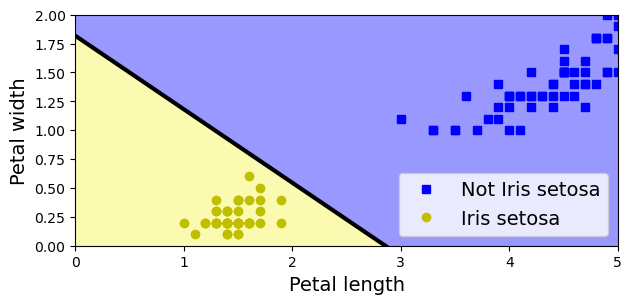

In [41]:
# extra code – plots the decision boundary of a Perceptron on the iris dataset

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]
b = -per_clf.intercept_ / per_clf.coef_[0, 1]
axes = [0, 5, 0, 2]
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = per_clf.predict(X_new)
zz = y_predict.reshape(x0.shape)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

plt.figure(figsize=(7, 3))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")
plt.plot([axes[0], axes[1]], [a * axes[0] + b, a * axes[1] + b], "k-",
         linewidth=3)
plt.contourf(x0, x1, zz, cmap=custom_cmap)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="lower right")
plt.axis(axes)
plt.show()

 **Retropropagación (Backpropagation)**  
Es la técnica de entrenamiento más utilizada en redes neuronales.

1. El entrenamiento se realiza procesando **mini-lotes** (mini-batches) del conjunto de datos.  
   - El modelo recorre todo el dataset varias veces; cada recorrido completo se denomina **época**.

2. Cada mini-lote se introduce en la red a través de la **capa de entrada**.

   - El algoritmo calcula la salida de las neuronas en la primera capa oculta.  
   - Estas salidas se propagan hacia adelante capa por capa hasta llegar a la **capa de salida**.  
   - Este proceso se conoce como **pase hacia adelante (forward pass)**.  
     - Es equivalente a hacer predicciones, pero almacenando todos los valores intermedios, ya que serán necesarios posteriormente.

   - Se calcula el error utilizando una **función de pérdida**, comparando la salida real con la esperada.

   - Luego, el algoritmo determina cuánto contribuyó cada peso y sesgo al error total, aplicando la **regla de la cadena**.

   - Este cálculo se realiza en sentido inverso, desde la capa de salida hasta la capa de entrada.  
     - A este proceso se le conoce como **pase hacia atrás (backward pass)**.

   - Finalmente, se actualizan los parámetros (pesos y sesgos) mediante **descenso del gradiente**, utilizando los gradientealculados.

---

### **Conclusión**

La retropropagación sigue estos pasos:

1. Realiza predicciones sobre un mini-lote (**forward pass**).  
2. Calcula el error (**función de pérdida**).  
3. Propaga el error hacia atrás para estimar la contribución de cada parámetro (**backward pass**).  
4. Ajusta los pesos y sesgos para reducir el error (**descenso del gradiente**).

**Nota:**  
Es fundamental inicializar aleatoriamente los pesos de las conexiones en todas las capas ocultas; de lo contrario, el entrenamiento fallará.  
Esto se debe a que la aleatoriedad **rompe la simetría**, permitiendo que la retropropagación entrene neuronas que aprendan características distintas.

- Para que **backpropagation** funcione correctamente, Rumelhart y sus colaboradores reemplazaron la función escalón por la **función logística (sigmoide)**, ya que es diferenciable y permite aplicar la **regla de la cadena** durante el entrenamiento.

**Función tangente hiperbólica: $\tanh(z)$**
- Es **continua y diferenciable** en todo su dominio.  
- Su rango de salida está entre $-1$ y $1$, lo que la hace **centrada en cero**.  
- Esta característica facilita el flujo del gradiente y puede **acelerar la convergencia** durante el entrenamiento.  

---

**Función lineal rectificada (ReLU): $ReLU(z)$**
- Es **continua**, pero **no diferenciable en $z = 0$** (aunque en la práctica esto no suele ser un problema).  
- Su derivada es:
  - $0$ para $z < 0$  
  - $1$ para $z > 0$  
- Es **computacionalmente eficiente**, lo que la hace muy popular en redes profundas.  
- Al no tener un límite superior en su salida, ayuda a **mitigar el problema del desvanecimiento del gradiente** y favorece un entrenamiento más eficiente.

**¿Por qué necesitamos funciones de activación?**

Si se encadenan varias transformaciones lineales, el resultado sigue siendo una **única transformación lineal**.
Supongamos que tenemos dos transformaciones lineales:

- Primera transformación:
  $$f(x) = 2x + 3 $$

- Segunda transformación:
  $$  g(x) = 4x - 1$$

Ahora encadenamos ambas funciones (composición):

$$h(x) = g(f(x))$$

Sustituyendo:

$$h(x) = 4(2x + 3) - 1$$

Simplificando:

$$h(x) = 8x + 12 - 1 = 8x + 11$$


  
Es decir, sin funciones de activación, una red neuronal profunda sería equivalente a un modelo lineal, sin importar cuántas capas tenga.

Las **funciones de activación introducen no linealidad**, lo cual es esencial para que la red pueda:
- Aprender **relaciones complejas** entre variables.  
- Capturar **patrones no lineales** en los datos.  
- Resolver problemas como clasificación, reconocimiento de imágenes o lenguaje natural.

Además:
- Permiten que cada capa aprenda **representaciones más abstractas** de los datos.  
- Hacen posible que la red modele **interacciones complejas** entre características.

Una red neuronal profunda (DNN) con activaciones no lineales puede, en teoría, **aproximar cualquier función continua**, propiedad conocida como el **teorema de aproximación universal**.

> Sin funciones de activación, una red profunda no sería más poderosa que una regresión lineal.

**Activation functions**

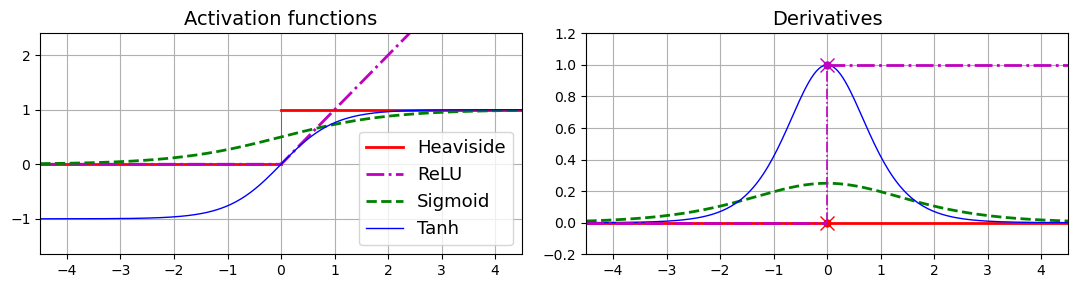

In [47]:
# extra code – this cell generates and saves Figure 10–8

from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

save_fig("activation_functions_plot")
plt.show()

## MLP de regresión.

**Advertencia**: En versiones recientes de Scikit-Learn, debe usar `root_mean_squared_error()` para calcular el RMSE, en lugar de `mean_squared_error(labels, predictions, squared=False)`. El siguiente bloque `try`/`except` intenta importar `root_mean_squared_error`, y si falla, simplemente lo define.

In [50]:
# Intentamos importar directamente la función más reciente de scikit-learn
# (disponible en versiones nuevas)
try:
    from sklearn.metrics import root_mean_squared_error

# Si falla la importación (porque la versión de scikit-learn es antigua),
# entramos al bloque except
except ImportError:
    # Importamos la función clásica de error cuadrático medio (MSE)
    from sklearn.metrics import mean_squared_error

    # Definimos manualmente la función RMSE para mantener compatibilidad
    def root_mean_squared_error(labels, predictions):
        # mean_squared_error con squared=False devuelve directamente la raíz (RMSE)
        return mean_squared_error(labels, predictions, squared=False)

In [51]:
from sklearn.datasets import fetch_california_housing # Importamos el dataset de precios de vivienda en California
from sklearn.model_selection import train_test_split # Función para dividir los datos en entrenamiento, validación y prueba
from sklearn.neural_network import MLPRegressor # Modelo de red neuronal tipo MLP para regresión
from sklearn.pipeline import make_pipeline # Pipeline para encadenar preprocesamiento + modelo
from sklearn.preprocessing import StandardScaler # Escalador para normalizar los datos (muy importante en redes neuronales)
# Cargamos el dataset

<code> fetch_california_housing() </code> contiene solo características numéricas y no hay valores faltantes.

In [53]:
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [54]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

1. Entrenamiento completo y prueba

In [56]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)

2. Entrenamiento y validación

In [58]:
# Segunda división: entrenamiento y validación
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)


3. **Definimos la red neuronal:**

   $3$ capas ocultas compuestas con $50$ neuronas cada una.



In [60]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
mlp_reg

MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)

4. Creamos un pipeline.
   - Escala los datos.
   - Entrena la red neuronal.

In [62]:
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(hidden_layer_sizes=[50, 50, 50],
                              random_state=42))])

4. Entrenamos el modelo con los datos de entrenamiento

In [64]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(hidden_layer_sizes=[50, 50, 50],
                              random_state=42))])

5. Hacemos predicciones sobre el conjunto de validación

In [66]:
y_pred = pipeline.predict(X_valid)
y_pred

array([1.28463736, 2.3567012 , 1.37453837, ..., 2.00380092, 1.63780066,
       1.98379911])

6. Calculamos el error **(RMSE)** entre valores reales y predichos.

In [68]:
rmse = root_mean_squared_error(y_valid, y_pred)
rmse

0.5053326657968586

## Classification MLPs

In [70]:
from sklearn.datasets import load_iris # Importamos el dataset Iris (clasificación de flores)
from sklearn.model_selection import train_test_split # Función para dividir datos en entrenamiento y prueba
from sklearn.neural_network import MLPClassifier # Modelo de red neuronal tipo perceptrón multicapa (MLP)
from sklearn.pipeline import make_pipeline # (Faltaban estos imports en tu código original)
from sklearn.preprocessing import StandardScaler

In [71]:
# Cargamos el dataset Iris
iris = load_iris()
iris.data[:5] #datas

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [72]:
iris.target_names #Variable objetivo

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [73]:
iris.feature_names #Características

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

1. Separamos el $10$\% de los datos de prueba (test)

In [75]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    iris.data, iris.target, test_size=0.1, random_state=42)

2. Del conjutno de entrenamiento completo, separamos un $10$\% para validacion

In [77]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42)

3. **Definimos el modelo MLP:**

   - <code> hidden_layer_sizes [5]: </code>  Una capa oculta con 5 neuronas.
   - <code> max_iter =1000 :</code> Número máximo de iteraciones para asegurar la convergencia.
   - <code>  random_state=42: </code> Para reproducibilidad.

In [79]:
mlp_clf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,
                        random_state=42)
mlp_clf

MLPClassifier(hidden_layer_sizes=[5], max_iter=10000, random_state=42)

4. Creamos un pipeline:
    - StandardScaler: normaliza los datos (muy importante para redes neuronales)
    - mlp_clf: modelo de red neuronal

In [81]:
pipeline = make_pipeline(StandardScaler(), mlp_clf)
pipeline

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[5], max_iter=10000,
                               random_state=42))])

5. Entrenamos el modelo con los datos de entrenamiento.

In [83]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[5], max_iter=10000,
                               random_state=42))])

6. Evaluamos el modeo usando el conjutno de validación

In [85]:
accuracy = pipeline.score(X_valid, y_valid)
accuracy

1.0

# Implementación de MLP con Keras
## Creación de un clasificador de imágenes mediante la API Sequential
### Carga del conjunto de datos con Keras

Comencemos cargando el conjunto de datos <code> fashion MNIST </code>. Keras cuenta con varias funciones para cargar conjuntos de datos populares en `tf.keras.datasets`. El conjunto de datos ya está dividido entre un conjunto de entrenamiento (60 000 imágenes) y un conjunto de prueba (10 000 imágenes), pero puede ser útil dividir aún más el conjunto de entrenamiento para obtener un conjunto de validación. Usaremos 55 000 imágenes para el entrenamiento y 5000 para la validación.

In [88]:
import tensorflow as tf # Importamos TensorFlow, que incluye Keras para trabajar con redes neuronales

**Cargamos el dataset Fashion MNIST:**
- Imágenes de ropa en escala de grises (28x28 píxeles)
- 10 clases (camisetas, zapatos, bolsas, etc.)

In [90]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
fashion_mnist

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

Separamos los datos en entrenamiento completo y prueba (test)
- $X$: imágenes
- $y$: etiquetas (clases)

In [92]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

In [93]:
total = len(X_train_full) + len(X_test) # Total de muestras
# Proporciones iniciales (train_full vs test)
train_full_prop = len(X_train_full) / total
test_prop = len(X_test) / total
print(
f"""Proporciones originales: Total de imágenes {total}
Entrenamiento completo: {len(X_train_full)} ({train_full_prop*100:.2f}%)
Prueba:       {len(X_test)} ({test_prop*100:.2f}%)
""")

Proporciones originales: Total de imágenes 70000
Entrenamiento completo: 60000 (85.71%)
Prueba:       10000 (14.29%)



Creamos el conjunto de entrenamiento:
- Tomamos todos los datos excepto los últimos $5,000$

In [95]:
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]

In [96]:
print(len(X_train))

55000


Creamos el conjunto de validación:
- Usamos los últimos $5,000$ ejemplos del entrenamiento original.
- Este conjunto se usa para evaluar el modelo durante el entrenamiento.

In [98]:
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [99]:
print(len(X_valid))

5000


El conjunto de entrenamiento contiene $60.000$ imágenes en escala de grises, cada una de $28$x$28$ píxeles:

In [101]:
X_train_full.shape

(60000, 28, 28)

**La intensidad de cada píxel se representa como un byte (de 0 a 255):**
- Ver el tipo de dato (byte = <code> uint8 </code>): Eso significa que cada píxel usa 1 byte (8 bits) → valores de 0 a 255

Valores de $0$ a $255$
- $0$ → negro absoluto (sin luz)
- $255$ → blanco total (máxima intensidad)
- Valores intermedios → tonos de gris

In [104]:
X_train_full.dtype #Revisamos el tipo de dato de la columna de entrenamiento

dtype('uint8')

In [105]:
print(X_train_full.min(), X_train_full.max()) # Otra forma de ver que va de 0 a 255, observamos los valores mínimo y máximos

0 255


Observemos como se ve la primer imagen.

In [107]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

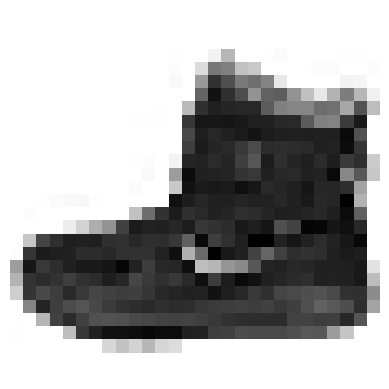

In [108]:
# cmap="binary":
# - Valores pequeños (cercanos a 0) → blanco
# - Valores grandes (cercanos a 255 o 1 si normalizaste) → negro
# Es decir: entre más grande el valor, más oscuro (negro)
plt.imshow(X_train[0], cmap="binary")
plt.axis('off') # Oculta los ejes para que solo se vea la imagen
plt.show() # Muestra la imagen

Vamos a reducir las intensidades de los píxeles al rango de 0 a 1 y convertirlas a números de coma flotante, dividiéndolas por 255:

In [110]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [111]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Puedes crear una imagen usando la función `imshow()` de Matplotlib, con un mapa de colores `'binario'`:s:

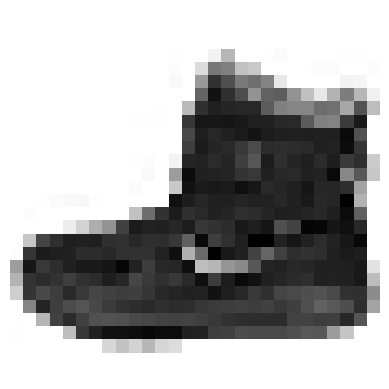

In [113]:
# cmap="binary":
# - Valores pequeños (cercanos a 0) → blanco
# - Valores grandes (cercanos a 255 o 1 si normalizaste) → negro
# Es decir: entre más grande el valor, más oscuro (negro)
plt.imshow(X_train[0], cmap="binary")
plt.axis('off') # Oculta los ejes para que solo se vea la imagen
plt.show() # Muestra la imagen

Las labes (etiquetas) son los identificadores de clase (representados como uint8), del 0 al 9:

In [115]:
len(y_train) #Número de etiquetas

55000

In [116]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

Aquí están los nombres de las clases correspondientes:

In [118]:
# Lista de nombres de las clases del dataset Fashion MNIST
# Cada posición del arreglo corresponde a una etiqueta numérica (0 a 9)

class_names = [
    "T-shirt/top",  # 0 → camiseta o top
    "Trouser",      # 1 → pantalón
    "Pullover",     # 2 → suéter
    "Dress",        # 3 → vestido
    "Coat",         # 4 → abrigo
    "Sandal",       # 5 → sandalia
    "Shirt",        # 6 → camisa
    "Sneaker",      # 7 → tenis (zapato deportivo)
    "Bag",          # 8 → bolsa
    "Ankle boot"    # 9 → botín
]

Así pues, la primera imagen del conjunto de entrenamiento es una bota de tobillo:

In [120]:
class_names[y_train[0]]

'Ankle boot'

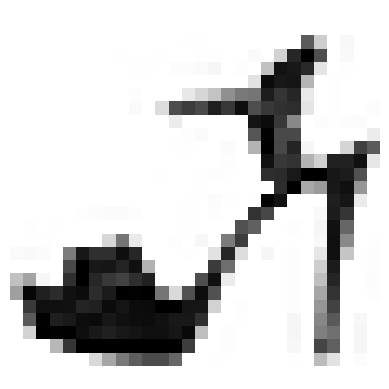

In [121]:
# cmap="binary":
# - Valores pequeños (cercanos a 0) → blanco
# - Valores grandes (cercanos a 255 o 1 si normalizaste) → negro
# Es decir: entre más grande el valor, más oscuro (negro)
plt.imshow(X_train[9], cmap="binary")
plt.axis('off') # Oculta los ejes para que solo se vea la imagen
plt.show() # Muestra la imagen

In [122]:
# Mostrar los primeros 15 valores de la variable objetivo
print("Primeros 15 valores de y_train:")
print(y_train[:50])

Primeros 15 valores de y_train:
[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9 1 0 6 4 3 1 4 8 4 3 0 2 4 4 5 3 6 6 0 8 5
 2 1 6 6 7 9 5 9 2 7 3 0 3]


Veamos una muestra de las imágenes del conjunto de datos:

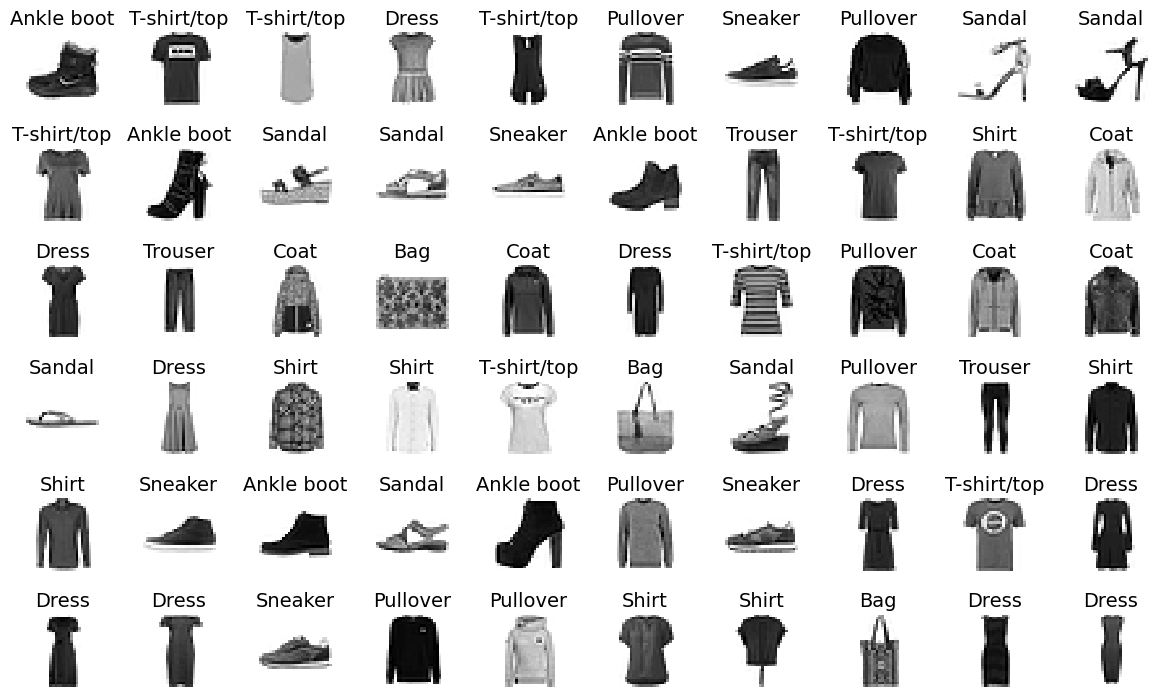

In [124]:
# Código extra – esta celda genera y guarda una figura con varias imágenes del dataset

# Número de filas y columnas que tendrá la cuadrícula de imágenes
n_rows = 6
n_cols = 10

# Se crea la figura, ajustando el tamaño en función de filas y columnas
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))

# Recorremos cada posición de la cuadrícula
for row in range(n_rows):
    for col in range(n_cols):
        
        # Calcula el índice de la imagen a mostrar
        index = n_cols * row + col
        
        # Define la posición del subplot dentro de la cuadrícula
        plt.subplot(n_rows, n_cols, index + 1)
        
        # Muestra la imagen correspondiente
        # cmap="binary": valores altos → negro, valores bajos → blanco
        # interpolation="nearest": evita suavizado, muestra píxeles tal cual
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        
        # Oculta los ejes para que solo se vea la imagen
        plt.axis('off')
        
        # Coloca el nombre de la clase como título de cada imagen
        plt.title(class_names[y_train[index]])

# Ajusta el espacio entre imágenes (horizontal y vertical)
plt.subplots_adjust(wspace=0.2, hspace=0.5)

# Guarda la figura con el nombre "fashion_mnist_plot"
save_fig("fashion_mnist_plot")

# Muestra la figura en pantalla
plt.show()

### Creación del modelo mediante la API secuencial

In [126]:
tf.random.set_seed(42) # Fijamos la semilla aleatoria de TensorFlow para reproducibilidad

Los pesos aleatorios de la capas ocultas y la capa de salida serán los mismos cada vez que se ejecute el notebook

In [128]:
model = tf.keras.Sequential() # Creamos un modelo secuencial (una pila de capas)

<code> tf.keras.Sequential() </code> es la forma más simple de crear un modelo de red neuronal en Keras/TensorFlow. 
**¿Qué es?**
- Es una clase que representa un modelo secuencial, es decir, una pila de capas apiladas una tras otra.
- Cada capa procesa la salida de la capa anterior y pasa sus resultados a la siguiente.
**Características principales**
- **Orden lineal:** Las capas se ejecutan en orden, de la primera a la última.
- **Fácil de usar:** Ideal para redes feedforward (MLP), CNN simples o modelos muy lineales.
- **Flexibilidad limitada:** No sirve directamente para modelos con múltiples entradas/salidas o rutas complejas (para eso se usa <code>tf.keras.Model </code> funcional).

Capa de entrada, especificanco la forma de los datos ($28$x$28$ píxeles)

In [131]:
model.add(tf.keras.layers.InputLayer(input_shape=[28, 28]))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 0 (0.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Aplanar la imagen $28$ x $28$ -> vector de $784$ elementos para pasarlo a la red

In [133]:
model.add(tf.keras.layers.Flatten())
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
Total params: 0 (0.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Cada **capa densa** gestiona su propia matriz de ponderaciones (weights), que contiene todas las conexiones entre **cada entrada y cada neurona** de la capa. Además, gestiona un **vector de términos de sesgo (bias)**, con un valor por cada neurona, que permite desplazar la función de activación y aumentar la capacidad de aprendizaje.

1era **capa densa (fully connected)** con $300$ neuronas y función de **activación ReLu**

In [136]:
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
Total params: 235500 (919.92 KB)
Trainable params: 235500 (919.92 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Formula: Para una **capa densa (fully connected)**:

**Parámetros totales**:

$$\text{Parámetros totales} = (\text{número de entradas} \times \text{número de neuronas}) + (\text{número de neuronas})$$


- El primer término → **pesos (weights)**: cada entrada se conecta a cada neurona.  
- El segundo término → **sesgos (bias)**: un valor de sesgo por cada neurona.

En este caso: 
$$\text{Parámetros totales} = (784 \times 300) + (300) = 235,200+300 = 235,500$$



In [138]:
import types
# Filtra los nombres que sean funciones
activations = [name for name in dir(tf.keras.activations)
               if isinstance(getattr(tf.keras.activations, name), types.FunctionType)]

print("Funciones de activación disponibles:")
print(activations)

Funciones de activación disponibles:
['deserialize', 'elu', 'exponential', 'gelu', 'get', 'hard_sigmoid', 'linear', 'mish', 'relu', 'selu', 'serialize', 'sigmoid', 'softmax', 'softplus', 'softsign', 'swish', 'tanh']


2da **capa densa** con $100$ neuronas y **activación ReLu**

In [140]:
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
Total params: 265600 (1.01 MB)
Trainable params: 265600 (1.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Para la **segunda capa densa**:

- Supongamos:
  - Número de **entradas** = salida de la capa anterior
  - Número de **neuronas** = cantidad de neuronas en esta capa

**Parámetros totales**:


$$\text{Parámetros totales} = (\text{número de entradas de la capa anterior} \times \text{número de neuronas}) + (\text{número de neuronas})$$

- Primer término → **pesos (weights)**: cada entrada de la capa anterior se conecta a cada neurona de esta capa.  
- Segundo término → **sesgos (bias)**: un valor de sesgo por cada neurona de la capa.




$$\text{Parámetros totales} = (300 \times 100) + (100)= 30,000+100=30,100$$


**Capa de salida con 10 neuronas (una por cada clase)** y **activación softmax** convierte los valores en probabilidades que suman 1

In [143]:
model.add(tf.keras.layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [144]:
#!pip install pydot
#!pip install graphviz
#https://graphviz.gitlab.io/download/ Descargar y poner en variables de entorno en PATH

In [145]:
import shutil
print(shutil.which("dot")) # Debe devolver la ruta completa al ejecutable, revisa si esta en la variable de entorno

C:\Program Files\Graphviz\bin\dot.EXE


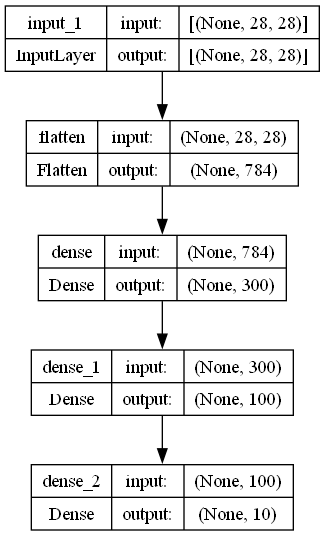

In [146]:
import pydot
import graphviz
# Código extra – otra forma de visualizar la arquitectura del modelo

# plot_model genera un diagrama gráfico del modelo y lo guarda como imagen
# Parámetros:
# - model: el modelo que queremos visualizar
# - "my_fashion_mnist_model.png": nombre del archivo donde se guardará la imagen
# - show_shapes=True: muestra la forma (shape) de la salida de cada capa en el diagrama

tf.keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

Obetenr la lista de capas de un modelo

In [148]:
model.layers

In [149]:
hidden1 = model.layers[1] # Accedemos a la primera capa oculta del modelo
hidden1.name # Mostramos el nombre asignado automáticamente por Keras

'dense'

In [150]:
hidden2 = model.layers[2] # Accedemos a la segunda capa oculta del modelo
hidden2.name # Mostramos el nombre asignado automáticamente por Keras

'dense_1'

In [151]:
hidden1 = model.layers[1] # hidden1 ya apunta a la primera capa Dense
# Verificamos que get_layer con el nombre devuelva la misma capa
print(model.get_layer('dense') is hidden1)  # Devuelve True

True


Se puede acceder a todos los parámetros de una capa mediante sus métodos <code> get_weights() </code> (devuelve una lista con dos elementos):
- [0] → matriz de pesos (weights)
- [1] → vector de sesgos (bias)

In [153]:
weights, biases = hidden1.get_weights()

In [154]:
weights #Lista de pesos

array([[-0.05035996,  0.03616489,  0.0467857 , ...,  0.06530496,
         0.0212099 ,  0.06838341],
       [-0.05630337, -0.01076753,  0.06866489, ...,  0.06297463,
         0.01281507,  0.02016597],
       [ 0.00991725,  0.00431775, -0.03558848, ..., -0.02641901,
        -0.02776726, -0.06720903],
       ...,
       [-0.0422058 , -0.05420559, -0.03236722, ..., -0.00717296,
         0.04673611,  0.03111017],
       [ 0.06222948,  0.00063434,  0.04357639, ..., -0.03338498,
        -0.07284766, -0.01897784],
       [-0.04021807,  0.05300964, -0.00611083, ...,  0.07161412,
         0.07332322,  0.04570065]], dtype=float32)

In [155]:
weights.shape

(784, 300)

In [156]:
biases # Sesgos

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

<code> tf.keras.layers.Dense(300, activation="relu") </code> en esta parte se inicializan los sesgos en $0$ por defecto. 
Si se desea utilizar un método de inicialización diferente, puede configurarlo **kernel_initializer** o **bias_initializer**. 

Por ejemplo:  

**from tensorflow.keras import initializers**


**tf.keras.layers.Dense( 300,    activation="relu",    bias_initializer=initializers.Constant(0.1))**

In [158]:
biases.shape

(300,)

### Compilando el modelo

In [160]:
model.compile(
    loss="sparse_categorical_crossentropy",  # Función de pérdida
    optimizer="sgd",                         # Optimizador
    metrics=["accuracy"]                     # Métricas a monitorear
)

Lo anterior es equivalente a:

In [162]:
# extra code – this cell is equivalent to the previous cell
model.compile(
    # Función de pérdida para clasificación multiclase con etiquetas enteras
    loss=tf.keras.losses.sparse_categorical_crossentropy,  
    
    # Optimizador: Descenso de Gradiente Estocástico (SGD)
    optimizer=tf.keras.optimizers.SGD(),                 
    
    # Métrica para evaluar exactitud en clasificación multiclase
    metrics=[tf.keras.metrics.sparse_categorical_accuracy]  
)

**Ejemplo:** 

Convertir etiquetas dispersas en etiquetas vectoriales one-hot, utilizando la función <code>  tf.keras.utils.to_categorical </code>

In [164]:
# extra code – shows how to convert class ids to one-hot vectors

# Ejemplo: tenemos 4 etiquetas de clase como enteros
y_int = [0, 5, 1, 0]

# Convertimos a one-hot vectors con 10 clases
y_one_hot = tf.keras.utils.to_categorical(y_int, num_classes=10)

y_one_hot

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

**Ejemplo:**

Concertir etiquetas one-hot en etiquetas dispersas.

Nota: es importante establecer `num_classes` cuando el número de clases sea mayor que el ID de clase máximo en la muestra.

In [166]:
# extra code – shows how to convert one-hot vectors to class ids
np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0], dtype=int64)

### Entrenamiento y evaluación del modelo

El tamaño de lote es $32$ por defecto, (<code> batch_size=None </code> o sin poner <code>   batch_size </code>)

In [169]:
len(X_train) #Imágenes de entrenamiento

55000

En entrenamiento de redes neuronales, **no se procesan todas las imágenes de golpe**, ya que sería demasiada memoría.
- Los datos se dividen en **batch_sizes (tamaños de lotes)**

En nuestro caso:

- $batch\_size = 32$ (cada lote contiene $32$ imágenes).
- $n\_samples = 55,000$ (tamaño de las imágenes en el entrenamiento)

El modelo procesa los datos en trozos de **batch_size** imágenes cada vez:

$$\text{num\_batches\_por\_epoca} = \left\lceil \frac{n\_samples}{batch\_size} \right\rceil = \left\lceil \frac{55,000}{32} \right\rceil  \left\lceil 1,718.75 \right\rceil = 1,719$$

Donde:
- $n\_samples$ = número de ejemplos de entrenamiento  
- $batch\_size$ = tamaño del lote  
- $\lceil \cdot \rceil$ = función  que redondea hacia arriba


Con esto tenemos que:

- Los primeros 1718 lotes tienen 32 imágenes cada uno

- El último lote tiene las 24 imágenes restantes

In [172]:
# Entrenamos el modelo
# X_train, y_train → datos de entrenamiento
# epochs=30 → número de veces que el modelo recorrerá todo el dataset de entrenamiento
# validation_data → datos de validación para monitorear performance durante el entrenamiento
history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_valid, y_valid)
)

Epoch 1/30


1719/1719 [==============================] - 11s 6ms/step - loss: 0.7248 - sparse_categorical_accuracy: 0.7623 - val_loss: 0.5085 - val_sparse_categorical_accuracy: 0.8202
Epoch 2/30
1719/1719 [==============================] - 9s 5ms/step - loss: 0.4879 - sparse_categorical_accuracy: 0.8314 - val_loss: 0.4592 - val_sparse_categorical_accuracy: 0.8366
Epoch 3/30
1719/1719 [==============================] - 10s 6ms/step - loss: 0.4417 - sparse_categorical_accuracy: 0.8456 - val_loss: 0.4211 - val_sparse_categorical_accuracy: 0.8526
Epoch 4/30
1719/1719 [==============================] - 10s 6ms/step - loss: 0.4177 - sparse_categorical_accuracy: 0.8530 - val_loss: 0.4010 - val_sparse_categorical_accuracy: 0.8564
Epoch 5/30
1719/1719 [==============================] - 10s 6ms/step - loss: 0.3975 - sparse_categorical_accuracy: 0.8601 - val_loss: 0.3905 - val_sparse_categorical_accuracy: 0.8614
Epoch 6/30
1719/1719 [==============================] - 10s 6ms/step - loss: 0.3815 

- La pérdida (loss) de entrenamiento disminuyó lo cual es buena señal.
- La precisión de validación alcanzó el $88.98$\% después de $30$ épocas. Esto es ligeramente inferior a la precisión de entrenamiento del $91.85$\%, por lo que hay un ligero sobreajuste, pero no excesivo.

En lugar de pasar explícitamente un conjunto de validación mediante el argumento <code>validation_data</code>, también se puede utilizar <code>validation_split</code> para indicar la proporción del conjunto de entrenamiento que se destinará a validación.

Por ejemplo, establecer <code>validation_split = 0.1</code> indica que se utilizará el último $10\%$ de los datos de entrenamiento (antes de la mezcla) como conjunto de validación.

In [175]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 1719}

<code> history </code> es el objeto que devuelve model.fit()
- Contiene información sobre cómo se entrenó el modelo

<code> history.params </code> es un diccionario con los parámetros del entrenamiento

Ejemplo de lo que puede contener:

- 'epochs' → número de épocas usadas en el entrenamiento
- 'steps' → número de lotes (batches) por época
- 'verbose' → nivel de detalle mostrado durante el entrenamiento

En particular:
steps = número de veces que el modelo actualiza sus pesos en una época (equivale al número de batches procesados por época)

In [177]:
# history.epoch es una lista que contiene los índices de las épocas completadas
print(history.epoch) #Cada número representa una época completa, es decir, una pasada completa por todo el conjunto de entrenamiento

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


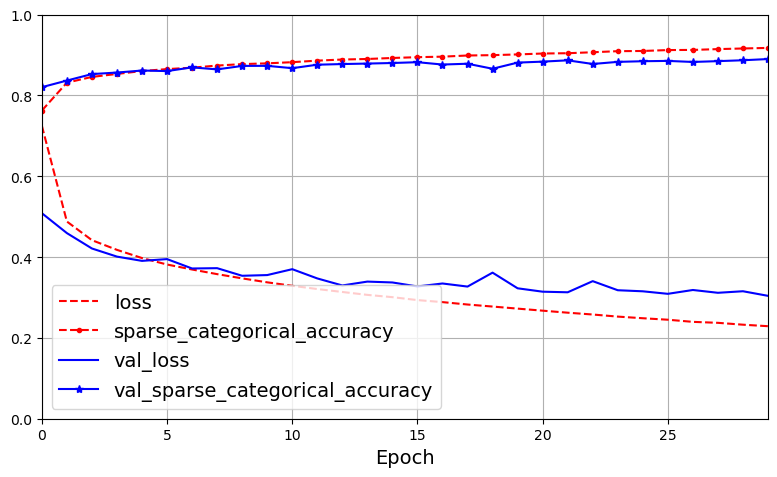

In [178]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertimos el historial de entrenamiento (history.history) en un DataFrame
# Esto contiene métricas como loss, accuracy, val_loss, val_accuracy por época
pd.DataFrame(history.history).plot(
    figsize=(8, 5),              # Tamaño de la figura
    xlim=[0, 29],                # Límite del eje X (épocas de 0 a 29)
    ylim=[0, 1],                 # Límite del eje Y (valores entre 0 y 1)
    grid=True,                   # Mostrar cuadrícula
    xlabel="Epoch",              # Etiqueta del eje X
    style=["r--", "r--.", "b-", "b-*"]  # Estilos de línea para cada métrica
)

# Ubicación de la leyenda en la gráfica
plt.legend(loc="lower left")  # extra code

# Guarda la figura generada con un nombre específico
save_fig("keras_learning_curves_plot")  # extra code

# Muestra la gráfica en pantalla
plt.show()

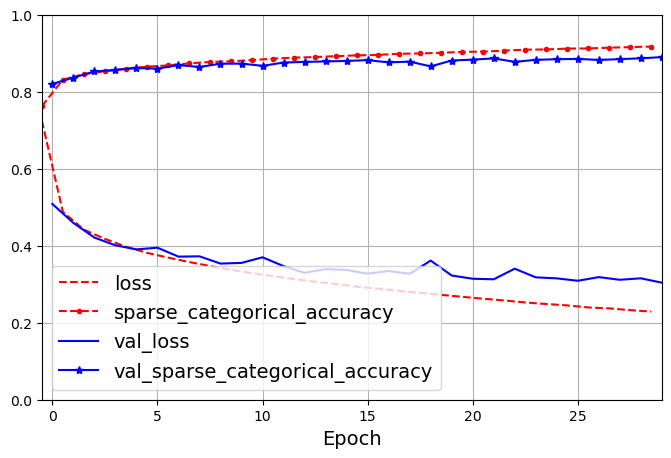

In [179]:
# extra code – shows how to shift the training curve by -1/2 epoch

# Creamos una nueva figura
plt.figure(figsize=(8, 5))

# Recorremos cada métrica del historial junto con su estilo de línea
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    
    # Convertimos las épocas a arreglo
    # Si es métrica de entrenamiento → desplazamos -0.5
    # Si es de validación (val_) → no se desplaza
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    
    # Graficamos la métrica correspondiente
    plt.plot(epochs, history.history[key], style, label=key)

# Etiqueta del eje X
plt.xlabel("Epoch")

# Límites de la gráfica: X de -0.5 a 29, Y de 0 a 1
plt.axis([-0.5, 29, 0., 1])

# Mostramos la leyenda
plt.legend(loc="lower left")

# Mostramos la cuadrícula
plt.grid()

# Mostramos la gráfica final
plt.show()

Evaluamos el modelo usando el conjunto de prueba (X_test, y_test). Esto permite medir qué tan bien generaliza el modelo con datos nuevos (no vistos durante el entrenamient

In [181]:
len(X_test)

10000

In [182]:
import math

# Número de lotes (redondeo hacia arriba)
num_batches = math.ceil(len(X_test) / 32)

num_batches

313

In [183]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 4ms/step - loss: 0.3223 - sparse_categorical_accuracy: 0.8862


[0.32231244444847107, 0.8862000107765198]

El método devuelve normalmente:
- loss → valor de la función de pérdida en el conjunto de prueba
- accuracy (u otra métrica definida) → desempeño del modelo en clasificación

### Uso del modelo para realizar predicciones

In [186]:
# Tomamos las primeras 3 imágenes del conjunto de prueba
X_new = X_test[:3]
X_new

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [187]:
len(X_new)

3

El modelo genera probabilidades para cada clase (salida softmax) Cada fila corresponde a una imagen y cada columna a una clase

In [189]:
y_proba = model.predict(X_new)
y_proba

1/1 [==============================] - 2s 2s/step


array([[0.00001579, 0.00000009, 0.0000105 , 0.00002676, 0.00001274,
        0.01113887, 0.00003589, 0.00827802, 0.00009898, 0.9803823 ],
       [0.00001381, 0.        , 0.9971654 , 0.00000004, 0.00159956,
        0.        , 0.00122113, 0.        , 0.00000002, 0.        ],
       [0.00002478, 0.9999722 , 0.00000022, 0.00000214, 0.00000058,
        0.        , 0.00000002, 0.        , 0.        , 0.        ]],
      dtype=float32)

Redondeamos las probabilidades a $2$ decimales para facilitar la lectura

In [191]:
y_proba.round(2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.01, 0.  , 0.98],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

Obtenemos la clase predicha para cada ejemplo.

<code> argmax(axis=-1)</code> busca el índice del valor máximo en cada fila (es decir, la clase con mayor probabilidad)

In [193]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1], dtype=int64)

In [194]:
# Convertimos la lista de nombres de clases en un array de NumPy
# Esto permite indexar fácilmente con otro array (y_pred)
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [195]:
# Tomamos las etiquetas reales de las primeras 3 imágenes del conjunto de prueba
y_new = y_test[:3]

# Mostramos las clases reales (en formato numérico)
y_new

array([9, 2, 1], dtype=uint8)

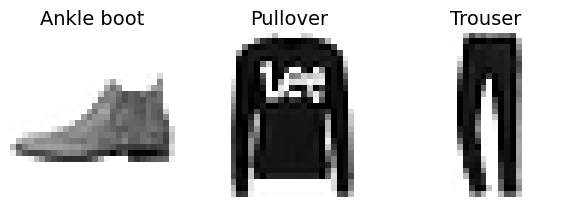

In [196]:
# extra code – this cell generates and saves Figure 10–12

# Creamos una figura con tamaño específico
plt.figure(figsize=(7.2, 2.4))

# Recorremos las imágenes nuevas (X_new contiene las primeras 3 imágenes)
for index, image in enumerate(X_new):
    
    # Creamos una subgráfica en una fila y 3 columnas
    # index + 1 → posición del subplot (1, 2, 3)
    plt.subplot(1, 3, index + 1)
    
    # Mostramos la imagen en escala de grises ("binary")
    plt.imshow(image, cmap="binary", interpolation="nearest")
    
    # Quitamos los ejes para que la imagen se vea limpia
    plt.axis('off')
    
    # Título de la imagen: clase real correspondiente
    plt.title(class_names[y_test[index]])

# Ajustamos el espacio entre subgráficas
plt.subplots_adjust(wspace=0.2, hspace=0.5)

# Guardamos la figura con un nombre específico
save_fig('fashion_mnist_images_plot', tight_layout=False)

# Mostramos la figura en pantalla
plt.show()

## Creación de una MLP de regresión mediante la API secuencial

Vamos a cargar, dividir y escalar el conjunto de datos de viviendas de California (el original, no el modificado como en el capítulo 2):

In [199]:
housing = fetch_california_housing() # Cargamos el dataset de precios de vivienda en California
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

1. Separamos el conjunto de entrenamiento completo y conjunto de prueba (test)

In [201]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data,    # Variables independientes (features)
    housing.target,  # Variable objetivo (precio de la vivienda)
    random_state=42  # Semilla para reproducibilidad
)

2.  Dividimos el conjunto de entrenamiento completo en:
- entrenamiento final
- validación

In [203]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42
)

In [204]:
tf.random.set_seed(42) # Fijamos la semilla para reproducibilidad (mismos resultados en cada ejecución)

3. Capa de normalización.
- Aprende la media y desviación estándar de los datos para escalarlos automáticamente.

In [206]:
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])
norm_layer

4. Definimos un modelo secuencial (capas en orden).

In [208]:
model = tf.keras.Sequential([
    norm_layer,  # Normaliza las entradas
    tf.keras.layers.Dense(50, activation="relu"),  # Capa oculta 1
    tf.keras.layers.Dense(50, activation="relu"),  # Capa oculta 2
    tf.keras.layers.Dense(50, activation="relu"),  # Capa oculta 3
    tf.keras.layers.Dense(1)  # Capa de salida (regresión → un solo valor)
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 8)                 17        
 on)                                                             
                                                                 
 dense_3 (Dense)             (None, 50)                450       
                                                                 
 dense_4 (Dense)             (None, 50)                2550      
                                                                 
 dense_5 (Dense)             (None, 50)                2550      
                                                                 
 dense_6 (Dense)             (None, 1)                 51        
                                                                 
Total params: 5618 (21.95 KB)
Trainable params: 5601 (21.88 KB)
Non-trainable params: 17 (72.00 Byte)
__________________

5. Definimos el optimizador Adam con tasa de aprendizaje de 0.001

In [210]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
optimizer

6. Compilamos el modelo:
- loss="mse" → error cuadrático medio (para regresión)
- optimizer → Adam
- metric → raíz del error cuadrático medio (más interpretable)

In [212]:
model.compile(
    loss="mse",
    optimizer=optimizer,
    metrics=["RootMeanSquaredError"]
)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizati  (None, 8)                 17        
 on)                                                             
                                                                 
 dense_3 (Dense)             (None, 50)                450       
                                                                 
 dense_4 (Dense)             (None, 50)                2550      
                                                                 
 dense_5 (Dense)             (None, 50)                2550      
                                                                 
 dense_6 (Dense)             (None, 1)                 51        
                                                                 
Total params: 5618 (21.95 KB)
Trainable params: 5601 (21.88 KB)
Non-trainable params: 17 (72.00 Byte)
__________________

7. La capa de normalización aprende estadísticas del conjunto de entrenamiento

In [214]:
norm_layer.adapt(X_train)

8. Entrenamos el modelo
- epochs=$20$ → $20$ pasadas por todo el dataset
- validation_data → usamos conjunto de validación

In [216]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid)
)
history

Epoch 1/20
363/363 [==============================] - 3s 5ms/step - loss: 0.8965 - root_mean_squared_error: 0.9468 - val_loss: 0.3881 - val_root_mean_squared_error: 0.6230
Epoch 2/20
363/363 [==============================] - 1s 3ms/step - loss: 0.3802 - root_mean_squared_error: 0.6166 - val_loss: 2.0691 - val_root_mean_squared_error: 1.4384
Epoch 3/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3742 - root_mean_squared_error: 0.6117 - val_loss: 0.4265 - val_root_mean_squared_error: 0.6531
Epoch 4/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3430 - root_mean_squared_error: 0.5857 - val_loss: 0.4108 - val_root_mean_squared_error: 0.6410
Epoch 5/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3292 - root_mean_squared_error: 0.5738 - val_loss: 0.3164 - val_root_mean_squared_error: 0.5625
Epoch 6/20
363/363 [==============================] - 1s 3ms/step - loss: 0.3200 - root_mean_squared_error: 0.5657 - val_loss: 0.5944 - val_

9. Evaluamos el modelo en el conjunto de prueba (datos no vistos)

Devuelve:

- mse_test → error cuadrático medio
- rmse_test → raíz del error cuadrático medio

In [218]:
mse_test, rmse_test = model.evaluate(X_test, y_test)

162/162 [==============================] - 0s 2ms/step - loss: 0.2899 - root_mean_squared_error: 0.5384


In [219]:
# Tomamos nuevos datos (primeras 3 observaciones del test)
X_new = X_test[:3]
# Generamos predicciones (valores continuos de precio de vivienda)
y_pred = model.predict(X_new)
y_pred

1/1 [==============================] - 0s 127ms/step


array([[0.39247632],
       [1.2341831 ],
       [5.4049416 ]], dtype=float32)

In [220]:
y_test[:3]

array([0.477  , 0.458  , 5.00001])

## Creación de modelos complejos mediante la API funcional


Las **redes no secuenciales** son modelos dentro de la Inteligencia Artificial y el Aprendizaje Automático que procesan datos **sin depender del orden temporal o secuencial** de la información.

**¿Qué significa “no secuencial”?**

A diferencia de modelos diseñados para datos ordenados en el tiempo (como texto, audio o series temporales), las redes no secuenciales tratan cada entrada como **independiente o sin relación de orden**.

**Ejemplos:**
- Una imagen → no importa qué píxel “va primero”
- Un conjunto de características (edad, peso, ingreso) → no hay secuencia

**Ejemplos de redes no secuenciales**

**1. Redes neuronales feedforward (Perceptrón multicapa)**
- La información fluye en una sola dirección (entrada → salida)
- No tienen memoria del pasado
- Son la base de muchos modelos clásicos

**2. Redes convolucionales (CNN)**
- Muy usadas en visión por computadora
- Detectan patrones espaciales en imágenes
- No procesan datos como secuencia, sino como estructura

**3. Árboles de decisión y modelos de conjunto**
- Ejemplo: Random Forest
- Analizan características sin considerar orden temporal
- No son redes neuronales, pero también son no secuenciales

**Diferencia con redes secuenciales**

| Característica          | Redes no secuenciales | Redes secuenciales |
|------------------------|----------------------|--------------------|
| Dependencia del orden  | ❌ No                | ✅ Sí              |
| Memoria                | ❌ No                | ✅ Sí              |
| Ejemplos               | MLP, CNN             | RNN, LSTM          |

**¿Cuándo se usan?**

Se utilizan cuando:
- Los datos no tienen estructura temporal
- El orden no afecta el resultado
- Se busca eficiencia y simplicidad

**Ejemplos de uso:**
- Clasificación de imágenes
- Detección de fraude

**Idea clave**

> Las redes no secuenciales son ideales cuando **la información importa por lo que es, no por cuándo aparece**.

Las **redes no secuenciales** son una categoría general de modelos que procesan datos **sin depender del orden**.

Un **MLP (Perceptrón Multicapa)** es **un tipo específico de red no secuencial**.

**Relación clave**

- Todas las MLP son redes no secuenciales  
- Pero no todas las redes no secuenciales son MLP  

**¿Qué es un MLP?**

Un MLP es una red neuronal donde:
- Las capas están completamente conectadas
- La información fluye de entrada → capas ocultas → salida
- No hay memoria ni manejo de secuencias

**Ejemplo de MLP:**
- Entrada: edad, ingreso, educación  
- Salida: probabilidad de compra  

No todos los modelos de redes neuronales son simplemente secuenciales. Algunos pueden tener topologías complejas. Algunos pueden tener múltiples entradas y/o múltiples salidas. Por ejemplo, una red neuronal Wide & Deep (véase [documento](https://ai.google/research/pubs/pub45413)) conecta todas o parte de las entradas directamente a la capa de salida.

Un ejemplo de una red neuronal no secuencial es una **red neuronal amplia y profunda**: Contecta todas o parte de las entradas directamenete a la capa de salida.

### Código

A continuación, abordaremos el problema de vivienda de California

Reinicia los contadores internos de nombres en Keras. Esto evita cinflictos o nombres duplicados de capas/modelos

In [243]:
tf.keras.backend.clear_session()

Fijamos la semilla aleatoria en <code> TensorFlow </code>. esto hace que los resultados sean reproducibles (mismos pesos iniciales, mismos resultados).

In [246]:
tf.random.set_seed(42)

1. **Capa de normalización:** Escala los datos de entrada para que tengan media $0$ y desviación estándara $1$

In [250]:
normalization_layer = tf.keras.layers.Normalization()
normalization_layer

2. **Primera capa oculta (densa):** $30$ neuronas con activación ReLU (introduce no linealidad)

In [254]:
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer1

3. **Segunda capa oculta (densa):** También con $30$ neuronas y ReLU

In [260]:
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2

4. **Capa de concatenación:** Se usa para unir diferentes tensores (en este caso, entrada original + salida profunda)

In [263]:
concat_layer = tf.keras.layers.Concatenate()
concat_layer

5. **Capa de salida:** $1$ neurona (típico para regresión) . Sin ninguna función de activación.

In [267]:
output_layer = tf.keras.layers.Dense(1)
output_layer

6. **Definición de la entrada**: 
<code> shape=X_train.shape[1:] </code> significa: número de características

In [274]:
X_train.shape[1:]

(8,)

In [270]:
input_ = tf.keras.layers.Input(shape=X_train.shape[1:])
input_

<KerasTensor: shape=(None, 8) dtype=float32 (created by layer 'input_1')>

7. **Se normalizan los datos de entrada:** Por eso se denomina **API funcional**

Una API funcional en Keras/TensorFlow es una forma de construir modelos de redes neuronales de manera flexible, permitiendo arquitecturas no lineales, múltiples entradas y múltiples salidas, a diferencia del modelo secuencial, que solo permite apilar capas de forma lineal.

In [277]:
normalized = normalization_layer(input_)
normalized

<KerasTensor: shape=(None, 8) dtype=float32 (created by layer 'normalization')>

8. **Paso por la primera capa oculta**

In [280]:
hidden1 = hidden_layer1(normalized)
hidden1

<KerasTensor: shape=(None, 30) dtype=float32 (created by layer 'dense')>

9. **Paso por la segunda capa oculta:**

In [283]:
hidden2 = hidden_layer2(hidden1)
hidden2

<KerasTensor: shape=(None, 30) dtype=float32 (created by layer 'dense_1')>

10. **Skip connection:** Se concatena la entrada original (ya normalizada) con la salida de la segunda capa oculta. Esto ayuda a preservar información original y mejorar el entrenamiento

In [286]:
concat = concat_layer([normalized, hidden2])
concat

<KerasTensor: shape=(None, 38) dtype=float32 (created by layer 'concatenate')>

11. **Capa salida final**

In [288]:
output = output_layer(concat)
output

<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'dense_2')>

12. **Se construye el modelo usando la API funcional**

In [294]:
model = tf.keras.Model(inputs=[input_], outputs=[output])
model

In [296]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 8)]                  0         []                            
                                                                                                  
 normalization (Normalizati  (None, 8)                    17        ['input_1[0][0]']             
 on)                                                                                              
                                                                                                  
 dense (Dense)               (None, 30)                   270       ['normalization[0][0]']       
                                                                                                  
 dense_1 (Dense)             (None, 30)                   930       ['dense[0][0]']           

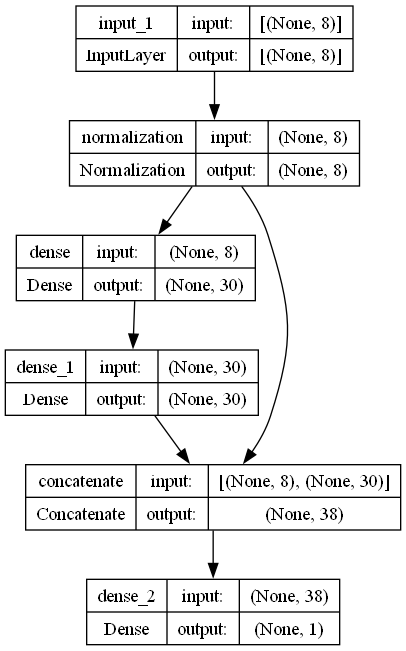

In [298]:
tf.keras.utils.plot_model(model, "my_vivienda_california_model.png", show_shapes=True)

**Resumen:**
- De la línea 1 a la 5, crean todas lascapas que necesitamos para construir el modelo.
- De la línea 6 a la 11, usan estas capas como funciones para ir de la entrada a la salida.
- La línea 12 crea un objeto <code> model </code>

13. Crear el optimizador **Adama** con tasa de aprendizaje $0.001$

In [305]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
optimizer

14. **Compilar el modelo**
- <code>loss="mse" </code>: función de pérdida para regresión (Mean Squared Error)
- <code>optimizer=optimizer </code>: método de optimización
- <code>metrics=["RootMeanSquaredError"] </code>: métrica para monitorear durante entrenamiento

In [309]:
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

15. **Ajustar la capa de normalización a los datos de entrenamiento:** Esto calcula la media y desviación estándar de cada característica

In [312]:
normalization_layer.adapt(X_train)

16. **Entrenar el modelo**
- X_train, y_train: datos de entrenamiento
- epochs=$20$: número de pasadas completas sobre los datos
- validation_data: se evalúa desempeño en datos de validación cada epoch

In [316]:
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 [==============================] - 3s 4ms/step - loss: 1.1017 - root_mean_squared_error: 1.0496 - val_loss: 1.1945 - val_root_mean_squared_error: 1.0929
Epoch 2/20
363/363 [==============================] - 1s 4ms/step - loss: 0.4503 - root_mean_squared_error: 0.6711 - val_loss: 0.9379 - val_root_mean_squared_error: 0.9685
Epoch 3/20
363/363 [==============================] - 1s 4ms/step - loss: 0.4054 - root_mean_squared_error: 0.6367 - val_loss: 0.5766 - val_root_mean_squared_error: 0.7593
Epoch 4/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3734 - root_mean_squared_error: 0.6111 - val_loss: 0.3668 - val_root_mean_squared_error: 0.6056
Epoch 5/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3615 - root_mean_squared_error: 0.6013 - val_loss: 0.4959 - val_root_mean_squared_error: 0.7042
Epoch 6/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3471 - root_mean_squared_error: 0.5892 - val_loss: 0.3276 - val_

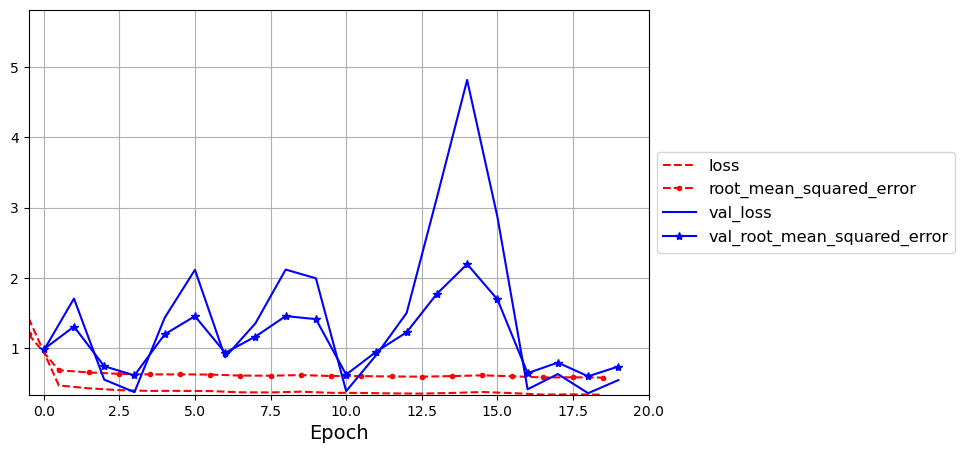

In [389]:
# extra code – shows how to shift the training curve by -1/2 epoch

# Creamos una nueva figura
plt.figure(figsize=(8, 5))

# Recorremos cada métrica del historial junto con su estilo de línea
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    
    # Convertimos las épocas a arreglo
    # Si es métrica de entrenamiento → desplazamos -0.5
    # Si es de validación (val_) → no se desplaza
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    
    # Graficamos la métrica correspondiente
    plt.plot(epochs, history.history[key], style, label=key)

# Etiqueta del eje X
plt.xlabel("Epoch")

# ===== AJUSTE DE EJES =====
# Eje X: de -0.5 hasta el número total de épocas
num_epochs = len(history.epoch)
plt.xlim(-0.5, num_epochs)

# Eje Y: mínimo y máximo de todos los datos del historial
all_values = np.concatenate(list(history.history.values()))
plt.ylim(np.min(all_values), np.max(all_values)+1)
# ==========================

# Mostrar la leyenda fuera del gráfico a la derecha y con letra más pequeña
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# Mostrar la cuadrícula
plt.grid()

# Mostrar la gráfica final
plt.show()

In [320]:
# history.epoch es una lista que contiene los índices de las épocas completadas
print(history.epoch) #Cada número representa una época completa, es decir, una pasada completa por todo el conjunto de entrenamiento

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


16. **Evaluar el modelo en datos de prueba:** Devuelve la pérdida (MSE) y las métricas definidas (RMSE)

In [323]:
mse_test = model.evaluate(X_test, y_test)
mse_test

162/162 [==============================] - 0s 2ms/step - loss: 0.3068 - root_mean_squared_error: 0.5539


[0.3067914843559265, 0.5538876056671143]

17. **Hacer predicciones con el modelo entrenado sobre nuevos datos**

In [341]:
y_pred = model.predict(X_new)
y_pred

1/1 [==============================] - 0s 47ms/step


array([[0.4448089],
       [1.3005992],
       [4.4959035]], dtype=float32)

¿Qué ocurre si queremos enviar diferentes subconjuntos de características de entrada a través de las rutas amplia o profunda?

- Enviaremos $5$ características (de la 0 a la 4)
- $$6 a través de la ruta profunda (de la 2 a la 7)

Cabe destacar que $3$ características pasarán por ambas rutas (las 2, 3 y 4).

In [345]:
tf.random.set_seed(42)  # extra code

In [347]:
# Definir la entrada "wide" (ancha) con 5 características (features 0 a 4)
input_wide = tf.keras.layers.Input(shape=[5])

# Definir la entrada "deep" (profunda) con 6 características (features 2 a 7)
input_deep = tf.keras.layers.Input(shape=[6])

# Crear capa de normalización para la rama "wide"
norm_layer_wide = tf.keras.layers.Normalization()

# Crear capa de normalización para la rama "deep"
norm_layer_deep = tf.keras.layers.Normalization()

# Aplicar normalización a la entrada wide
norm_wide = norm_layer_wide(input_wide)

# Aplicar normalización a la entrada deep
norm_deep = norm_layer_deep(input_deep)

# Primera capa oculta para la rama "deep"
# 30 neuronas con activación ReLU
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)

# Segunda capa oculta para la rama "deep"
# 30 neuronas con activación ReLU
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)

# Concatenar la rama "wide" normalizada con la salida profunda de la rama "deep"
# Esto combina información de características crudas y transformadas
concat = tf.keras.layers.concatenate([norm_wide, hidden2])

# Capa de salida final (1 neurona, típica para regresión)
output = tf.keras.layers.Dense(1)(concat)

# Definir el modelo usando la API funcional
# El modelo tiene dos entradas (wide y deep) y una salida
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

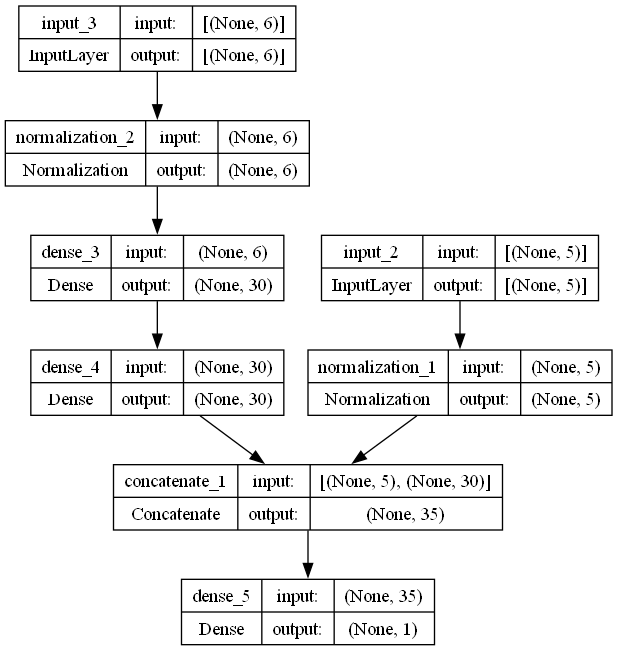

In [351]:
tf.keras.utils.plot_model(model, "my_vivienda_california_model_multiplesentradas.png", show_shapes=True)

In [355]:
# Crear el optimizador Adam con tasa de aprendizaje 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Compilar el modelo
# - loss="mse": función de pérdida para regresión (Mean Squared Error)
# - optimizer=optimizer: optimizador Adam
# - metrics=["RootMeanSquaredError"]: métrica para monitorear durante entrenamiento
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

In [361]:
X_train.shape

(11610, 8)

In [363]:
# ============================
# Dividir los datos en ramas "wide" y "deep"
# ============================

# Ramas "wide" (primeras 5 características)
# - Se usan directamente para que el modelo aprenda relaciones lineales simples
# - Aquí se toman columnas 0, 1, 2, 3 y 4
X_train_wide = X_train[:, :5]
X_valid_wide = X_valid[:, :5]
X_test_wide  = X_test[:, :5]

# Ramas "deep" (características 2 a 7)
# - Pasan por capas ocultas para aprender relaciones no lineales complejas
# - Se toman columnas 2, 3, 4, 5, 6, 7
# - Observa que columnas 2,3,4 están **en ambas ramas** (solapamiento intencional)
X_train_deep = X_train[:, 2:]
X_valid_deep = X_valid[:, 2:]
X_test_deep  = X_test[:, 2:]

# Preparar algunos ejemplos nuevos para hacer predicciones rápidas
# - Seleccionamos los primeros 3 ejemplos del test
# - X_new_wide = primera 5 columnas
# - X_new_deep = columnas 2 a 7
X_new_wide = X_test_wide[:3]
X_new_deep = X_test_deep[:3]  # 3 ejemplos nuevos para predecir

In [365]:
# Ajustar las capas de normalización a los datos de entrenamiento
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

In [367]:
# Entrenar el modelo
# - Entradas: tuplas (wide, deep)
# - Salida: y_train
# - epochs=20: número de iteraciones sobre todo el dataset
# - validation_data: datos de validación
history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20,
                    validation_data=((X_valid_wide, X_valid_deep), y_valid))


Epoch 1/20
363/363 [==============================] - 3s 5ms/step - loss: 1.4258 - root_mean_squared_error: 1.1941 - val_loss: 0.9660 - val_root_mean_squared_error: 0.9829
Epoch 2/20
363/363 [==============================] - 1s 4ms/step - loss: 0.4671 - root_mean_squared_error: 0.6835 - val_loss: 1.7047 - val_root_mean_squared_error: 1.3056
Epoch 3/20
363/363 [==============================] - 1s 4ms/step - loss: 0.4263 - root_mean_squared_error: 0.6529 - val_loss: 0.5503 - val_root_mean_squared_error: 0.7418
Epoch 4/20
363/363 [==============================] - 2s 4ms/step - loss: 0.4003 - root_mean_squared_error: 0.6327 - val_loss: 0.3726 - val_root_mean_squared_error: 0.6104
Epoch 5/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3899 - root_mean_squared_error: 0.6245 - val_loss: 1.4311 - val_root_mean_squared_error: 1.1963
Epoch 6/20
363/363 [==============================] - 1s 4ms/step - loss: 0.3907 - root_mean_squared_error: 0.6251 - val_loss: 2.1138 - val_

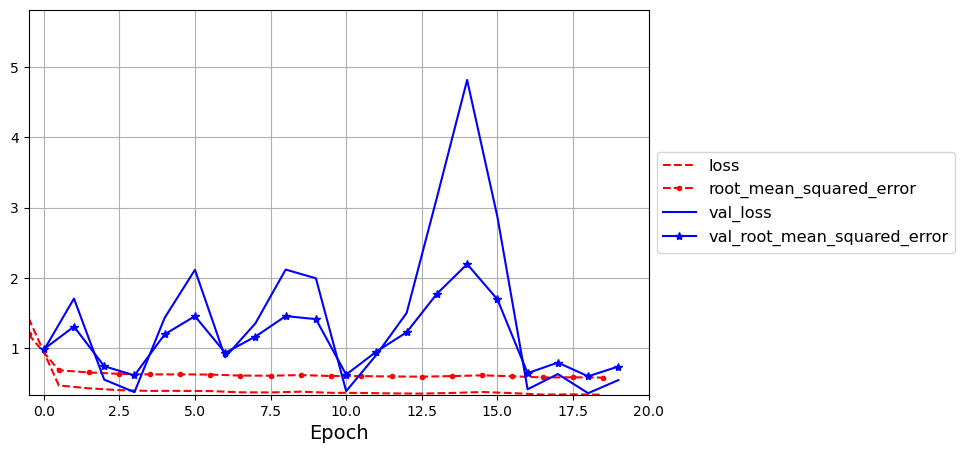

In [387]:
# extra code – shows how to shift the training curve by -1/2 epoch

# Creamos una nueva figura
plt.figure(figsize=(8, 5))

# Recorremos cada métrica del historial junto con su estilo de línea
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    
    # Convertimos las épocas a arreglo
    # Si es métrica de entrenamiento → desplazamos -0.5
    # Si es de validación (val_) → no se desplaza
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    
    # Graficamos la métrica correspondiente
    plt.plot(epochs, history.history[key], style, label=key)

# Etiqueta del eje X
plt.xlabel("Epoch")

# ===== AJUSTE DE EJES =====
# Eje X: de -0.5 hasta el número total de épocas
num_epochs = len(history.epoch)
plt.xlim(-0.5, num_epochs)

# Eje Y: mínimo y máximo de todos los datos del historial
all_values = np.concatenate(list(history.history.values()))
plt.ylim(np.min(all_values), np.max(all_values)+1)
# ==========================

# Mostrar la leyenda fuera del gráfico a la derecha y con letra más pequeña
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# Mostrar la cuadrícula
plt.grid()

# Mostrar la gráfica final
plt.show()

In [391]:

# Evaluar el modelo en datos de prueba
# Devuelve pérdida (MSE) y métricas definidas (RMSE)
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)

162/162 [==============================] - 0s 2ms/step - loss: 0.3338 - root_mean_squared_error: 0.5778


In [395]:
# Hacer predicciones sobre nuevos datos
y_pred = model.predict((X_new_wide, X_new_deep))
y_pred

1/1 [==============================] - 0s 32ms/step


array([[0.34549496],
       [1.1989753 ],
       [3.4430666 ]], dtype=float32)

### Múltiples salidas como técnica de regularización



En redes neuronales, a veces definimos un modelo con más de una salida. Cada salida tiene su propia función de pérdida, y el modelo intenta minimizar todas al mismo tiempo.

**Idea clave:**  
Forzar a la red a predecir varias tareas relacionadas evita que se concentre únicamente en un objetivo. Esto actúa como una restricción durante el entrenamiento, limitando el sobreajuste. Como resultado, el modelo aprende representaciones más generales que funcionan mejor con datos nuevos.

**Ejemplo conceptual:**  
Supongamos que tenemos un dataset para predecir el precio de casas. Podríamos definir un modelo con dos salidas:  
1. Predicción del precio de la casa.  
2. Predicción de la superficie de la casa.

Durante el entrenamiento, el modelo aprende a minimizar la pérdida combinada de ambas salidas. Esto obliga a la red a aprender representaciones útiles para ambos objetivos, reduciendo la probabilidad de sobreajuste.

**Beneficios de múltiples salidas para regularización:**  
- Reduce el sobreajuste al distribuir la atención de la red en varias tareas.  
- Mejora la generalización porque la red aprende patrones más robustos.  
- Permite aprovechar tareas relacionadas para aprender representaciones compartidas, acelerando el entrenamiento y mejorando la predicción.

In [417]:
# Limpiamos la sesión de Keras actual para liberar memoria
# Esto es útil si vamos a crear y entrenar varios modelos seguidos, evitando que se acumulen gráficos y pesos antiguos
tf.keras.backend.clear_session()

# Fijamos la semilla aleatoria de TensorFlow para reproducibilidad
# Esto garantiza que operaciones aleatorias (inicialización de pesos, dropout, shuffling, etc.) 
# den los mismos resultados cada vez que ejecutemos el código
tf.random.set_seed(42)

In [419]:
# Definimos la entrada "wide" con 5 características (features 0 a 4)
input_wide = tf.keras.layers.Input(shape=[5])  

# Definimos la entrada "deep" con 6 características (features 2 a 7)
input_deep = tf.keras.layers.Input(shape=[6])  

# Creamos capas de normalización para cada entrada
norm_layer_wide = tf.keras.layers.Normalization()  
norm_layer_deep = tf.keras.layers.Normalization()  

# Aplicamos la normalización a las entradas
norm_wide = norm_layer_wide(input_wide)  
norm_deep = norm_layer_deep(input_deep)  

# Construimos la parte "deep" con dos capas densas de 30 neuronas cada una y activación ReLU
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)  
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)  

# Concatenamos la salida normalizada de la parte "wide" con la salida de la parte "deep"
concat = tf.keras.layers.concatenate([norm_wide, hidden2])  

# Capa de salida principal que combina la información "wide" y "deep"
output = tf.keras.layers.Dense(1)(concat)  

# Capa de salida auxiliar que solo usa la parte "deep"
aux_output = tf.keras.layers.Dense(1)(hidden2)  

# Definimos el modelo con dos entradas y dos salidas
model = tf.keras.Model(inputs=[input_wide, input_deep],
                       outputs=[output, aux_output])

**Advertencia**: en versiones recientes, Keras requiere una métrica por salida, por lo que reemplacé `metrics=["RootMeanSquaredError"]` con `metrics=["RootMeanSquaredError", "RootMeanSquaredError"]` en el código a continuación.

In [429]:
# Definimos el optimizador Adam con una tasa de aprendizaje de 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Compilamos el modelo
model.compile(
    # Definimos la función de pérdida para cada salida
    # La primera pérdida corresponde a 'output', la segunda a 'aux_output'
    loss=("mse", "mse"),  
    
    # Asignamos pesos a cada pérdida: 0.9 para la principal y 0.1 para la auxiliar
    # Esto significa que la pérdida principal tiene más importancia al entrenar
    loss_weights=(0.9, 0.1),  
    
    # Usamos el optimizador definido arriba
    optimizer=optimizer,  
    
    # Métricas que queremos monitorizar durante el entrenamiento
    # En este caso, el error cuadrático medio raíz (RMSE) para ambas salidas
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse_main"),
             tf.keras.metrics.RootMeanSquaredError(name="rmse_aux")]
)

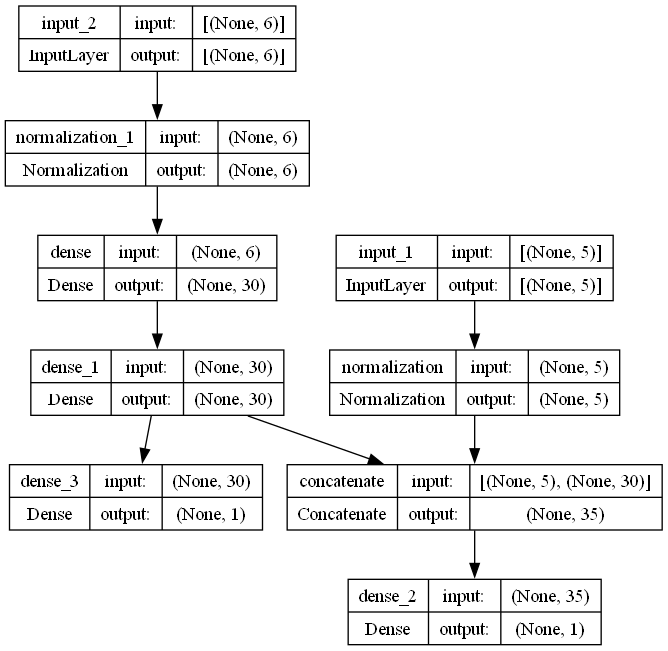

In [431]:
tf.keras.utils.plot_model(model, "my_vivienda_california_model_regresionmultisalida.png", show_shapes=True)

In [433]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 6)]                  0         []                            
                                                                                                  
 normalization_1 (Normaliza  (None, 6)                    13        ['input_2[0][0]']             
 tion)                                                                                            
                                                                                                  
 input_1 (InputLayer)        [(None, 5)]                  0         []                            
                                                                                                  
 dense (Dense)               (None, 30)                   210       ['normalization_1[0][0]'] 

In [435]:
# Ajustamos la capa de normalización "wide" usando los datos de entrenamiento
# Esto calcula la media y desviación estándar para normalizar las características
norm_layer_wide.adapt(X_train_wide)

# Ajustamos la capa de normalización "deep" usando los datos de entrenamiento
norm_layer_deep.adapt(X_train_deep)

# Entrenamos el modelo
history = model.fit(
    # Entradas del modelo: tuple con features "wide" y "deep"
    (X_train_wide, X_train_deep),  
    
    # Salidas del modelo: tuple con las etiquetas para la salida principal y auxiliar
    (y_train, y_train),  
    
    # Número de épocas para entrenar
    epochs=20,
    
    # Datos de validación para monitorizar el desempeño durante el entrenamiento
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
363/363 [==============================] - 4s 5ms/step - loss: 1.7574 - dense_2_loss: 1.6963 - dense_3_loss: 2.3070 - dense_2_rmse_main: 1.3024 - dense_2_rmse_aux: 1.3024 - dense_3_rmse_main: 1.5189 - dense_3_rmse_aux: 1.5189 - val_loss: 1.2616 - val_dense_2_loss: 0.6967 - val_dense_3_loss: 6.3453 - val_dense_2_rmse_main: 0.8347 - val_dense_2_rmse_aux: 0.8347 - val_dense_3_rmse_main: 2.5190 - val_dense_3_rmse_aux: 2.5190
Epoch 2/20
363/363 [==============================] - 1s 4ms/step - loss: 0.6233 - dense_2_loss: 0.6096 - dense_3_loss: 0.7467 - dense_2_rmse_main: 0.7807 - dense_2_rmse_aux: 0.7807 - dense_3_rmse_main: 0.8641 - dense_3_rmse_aux: 0.8641 - val_loss: 2.6063 - val_dense_2_loss: 2.4525 - val_dense_3_loss: 3.9899 - val_dense_2_rmse_main: 1.5661 - val_dense_2_rmse_aux: 1.5661 - val_dense_3_rmse_main: 1.9975 - val_dense_3_rmse_aux: 1.9975
Epoch 3/20
363/363 [==============================] - 1s 4ms/step - loss: 0.5322 - dense_2_loss: 0.5265 - dense_3_loss: 0.5826 -

**Advertencia**: en versiones recientes de TF, `evaluate()` también devuelve la métrica principal y la métrica auxiliar. Para garantizar que el código funcione tanto en versiones antiguas como nuevas, solo consideramos los primeros 3 elementos de `eval_results` (es decir, solo las pérdidas):

In [438]:
# Evaluamos el modelo con los datos de prueba
# Las entradas son un tuple con las features "wide" y "deep"
# Las salidas son un tuple con las etiquetas para la salida principal y auxiliar
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))

# Extraemos los resultados de evaluación
# eval_results es una lista con:
# [pérdida total ponderada, pérdida de la salida principal, pérdida de la salida auxiliar, 
#  métricas de la salida principal, métricas de la salida auxiliar...]
weighted_sum_of_losses, main_loss, aux_loss = eval_results[:3]

# weighted_sum_of_losses -> pérdida total ponderada según loss_weights
# main_loss -> pérdida individual de la salida principal
# aux_loss -> pérdida individual de la salida auxiliar

162/162 [==============================] - 1s 3ms/step - loss: 0.3282 - dense_2_loss: 0.3229 - dense_3_loss: 0.3766 - dense_2_rmse_main: 0.5682 - dense_2_rmse_aux: 0.5682 - dense_3_rmse_main: 0.6137 - dense_3_rmse_aux: 0.6137


In [444]:
# Realizamos predicciones con el modelo usando nuevas entradas
# Las entradas son un tuple con las features "wide" y "deep"
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

1/1 [==============================] - 0s 40ms/step


In [442]:
y_pred_main

array([[0.3419953],
       [1.1648322],
       [3.4300554]], dtype=float32)

In [446]:
y_pred_aux

array([[0.3582964 ],
       [0.93830997],
       [3.146454  ]], dtype=float32)

In [448]:
# Realizamos predicciones con el modelo usando nuevas entradas
# Las entradas son un tuple con las features "wide" y "deep"
y_pred_tuple = model.predict((X_new_wide, X_new_deep))

# Convertimos la tupla de predicciones en un diccionario
# Esto facilita acceder a cada salida por su nombre en lugar de por posición
# model.output_names contiene los nombres de las salidas: ["dense_2", "dense_3"] u otros que hayas definido
y_pred = dict(zip(model.output_names, y_pred_tuple))

# Ahora podemos acceder a las predicciones así:
# y_pred["output"] -> predicciones de la salida principal
# y_pred["aux_output"] -> predicciones de la salida auxiliar

1/1 [==============================] - 0s 58ms/step


## Uso de la API de subclases para construir modelos dinámicos

In [454]:
# Definimos una clase personalizada de modelo Wide & Deep heredando de tf.keras.Model
class WideAndDeepModel(tf.keras.Model):
    
    # Constructor del modelo, permite configurar unidades y activación de las capas "deep"
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)  # Llamamos al constructor base para permitir nombrar el modelo
        
        # Capas de normalización para las entradas "wide" y "deep"
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        
        # Capas densas de la parte "deep"
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        
        # Capa de salida principal (wide + deep)
        self.main_output = tf.keras.layers.Dense(1)
        
        # Capa de salida auxiliar (solo deep)
        self.aux_output = tf.keras.layers.Dense(1)
        
    # Definimos el método call, que especifica el flujo de datos en el modelo
    def call(self, inputs):
        # Separa las entradas en "wide" y "deep"
        input_wide, input_deep = inputs
        
        # Normalizamos las entradas
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        
        # Paso por las capas densas de la parte "deep"
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        
        # Concatenamos la parte "wide" con la salida final de la parte "deep"
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        
        # Calculamos la salida principal (wide + deep)
        output = self.main_output(concat)
        
        # Calculamos la salida auxiliar (solo deep)
        aux_output = self.aux_output(hidden2)
        
        # Retornamos ambas salidas como una tupla
        return output, aux_output

# Fijamos la semilla aleatoria para reproducibilidad
tf.random.set_seed(42)

# Creamos una instancia del modelo Wide & Deep personalizado
# Aquí usamos 30 unidades en cada capa "deep", activación ReLU, y le damos un nombre al modelo
model = WideAndDeepModel(30, activation="relu", name="my_cool_model")
model

**Advertencia**: como se explicó anteriormente, Keras ahora requiere una pérdida y una métrica por salida, por lo que reemplacé `loss="mse"` con `loss=["mse", "mse"]` y también reemplacé `metrics=["RootMeanSquaredError"]` con `metrics=["RootMeanSquaredError", "RootMeanSquaredError"]` en el código a continuación.

In [458]:
# Definimos el optimizador Adam con una tasa de aprendizaje de 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Compilamos el modelo Wide & Deep
model.compile(
    # Función de pérdida para cada salida: mse (error cuadrático medio)
    loss=["mse", "mse"],  
    
    # Pesos de cada pérdida: 0.9 para la salida principal, 0.1 para la auxiliar
    # Esto da más importancia a la salida principal durante el entrenamiento
    loss_weights=[0.9, 0.1],  
    
    # Optimizer definido arriba
    optimizer=optimizer,  
    
    # Métricas para monitorizar durante el entrenamiento
    # Aquí se aplican a ambas salidas
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse_main"),
             tf.keras.metrics.RootMeanSquaredError(name="rmse_aux")]
)

# Ajustamos la capa de normalización "wide" usando los datos de entrenamiento
# Esto calcula la media y desviación estándar de X_train_wide
model.norm_layer_wide.adapt(X_train_wide)

# Ajustamos la capa de normalización "deep" usando los datos de entrenamiento
model.norm_layer_deep.adapt(X_train_deep)

# Entrenamos el modelo
history = model.fit(
    # Entradas del modelo: features "wide" y "deep"
    (X_train_wide, X_train_deep),  
    
    # Salidas del modelo: etiquetas para salida principal y auxiliar
    (y_train, y_train),  
    
    # Número de épocas
    epochs=10,
    
    # Datos de validación para monitorizar desempeño durante el entrenamiento
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

# Evaluamos el modelo en el set de prueba
# Devuelve una lista con: pérdida total ponderada, pérdidas individuales y métricas
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))

# Realizamos predicciones sobre nuevos datos
# Devuelve una tupla con las predicciones de la salida principal y auxiliar
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

Epoch 1/10
363/363 [==============================] - 4s 6ms/step - loss: 1.5608 - output_1_loss: 1.4974 - output_2_loss: 2.1310 - output_1_rmse_main: 1.2237 - output_1_rmse_aux: 1.2237 - output_2_rmse_main: 1.4598 - output_2_rmse_aux: 1.4598 - val_loss: 2.9844 - val_output_1_loss: 2.2851 - val_output_2_loss: 9.2785 - val_output_1_rmse_main: 1.5116 - val_output_1_rmse_aux: 1.5116 - val_output_2_rmse_main: 3.0461 - val_output_2_rmse_aux: 3.0461
Epoch 2/10
363/363 [==============================] - 1s 4ms/step - loss: 0.5906 - output_1_loss: 0.5558 - output_2_loss: 0.9036 - output_1_rmse_main: 0.7455 - output_1_rmse_aux: 0.7455 - output_2_rmse_main: 0.9506 - output_2_rmse_aux: 0.9506 - val_loss: 1.7639 - val_output_1_loss: 1.1956 - val_output_2_loss: 6.8787 - val_output_1_rmse_main: 1.0934 - val_output_1_rmse_aux: 1.0934 - val_output_2_rmse_main: 2.6227 - val_output_2_rmse_aux: 2.6227
Epoch 3/10
363/363 [==============================] - 1s 4ms/step - loss: 0.4854 - output_1_loss: 0.4627

## Cómo guardar y restaurar un modelo

**Advertencia**: Keras ahora recomienda usar el formato `.keras` para guardar modelos y el formato `h5` para pesos. Por lo tanto, he actualizado el código en esta sección para mostrar primero qué debes cambiar si aún quieres usar el formato `SavedModel` de TensorFlow y luego cómo puedes usar los formatos recomendados.

In [513]:
# Importamos el módulo shutil, que permite operaciones con archivos y directorios
import shutil

# Eliminamos el directorio "my_keras_model" si ya existe
# Esto evita errores al guardar un nuevo modelo en la misma ruta
# ignore_errors=True significa que no dará error si el directorio no existe
shutil.rmtree("my_keras_model", ignore_errors=True)

In [515]:
# Guardamos el modelo Wide & Deep completo en el directorio "my_keras_model"
# Usamos el formato TensorFlow SavedModel (save_format="tf")
# Esto asegura que se guarde:
# 1. La arquitectura del modelo
# 2. Los pesos entrenados
# 3. La metadata de Keras (keras_metadata.pb)
# 4. Las capas de normalización adaptadas, listas para usar en inferencia
model.save("my_keras_model", save_format="tf")

INFO:tensorflow:Assets written to: my_keras_model\assets


INFO:tensorflow:Assets written to: my_keras_model\assets


In [517]:
# Importamos Path de pathlib para trabajar con rutas de manera cómoda
from pathlib import Path

# Recorremos todos los archivos y subdirectorios dentro de "my_keras_model"
# sorted() asegura que los veamos en orden alfabético
# "**/*" significa: todos los archivos y carpetas de manera recursiva
for path in sorted(Path("my_keras_model").glob("**/*")):
    # Imprimimos la ruta completa de cada archivo o carpeta
    print(path)

my_keras_model\assets
my_keras_model\fingerprint.pb
my_keras_model\keras_metadata.pb
my_keras_model\saved_model.pb
my_keras_model\variables
my_keras_model\variables\variables.data-00000-of-00001
my_keras_model\variables\variables.index


**Advertencia**: En Keras 3, ya no es posible cargar un `SavedModel` de TensorFlow como un modelo de Keras. Sin embargo, puede cargar un `SavedModel` como una capa `tf.keras.layers.TFSMLayer`, pero tenga en cuenta que esta capa solo se puede usar para inferencia: no para entrenamiento.

In [519]:
import tensorflow as tf

# Versión de TensorFlow
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.15.0


In [521]:
loaded_model = tf.keras.models.load_model("my_keras_model")

In [525]:
# Ignora todos los mensajes de advertencia de TensorFlow
tf.get_logger().setLevel('ERROR')
# Convertimos las nuevas features "wide" a un arreglo NumPy de tipo float32
# Esto asegura que TensorFlow reciba tensores con un tipo consistente
X_wide_new = np.array(X_new_wide, dtype=np.float32)

# Convertimos las nuevas features "deep" a un arreglo NumPy de tipo float32
X_deep_new = np.array(X_new_deep, dtype=np.float32)

# Realizamos predicciones con el modelo cargado
# Entradas: tuple con las features wide y deep
# Salidas: tupla con la predicción principal y la predicción auxiliar
y_pred_main, y_pred_aux = loaded_model.predict((X_wide_new, X_deep_new))

1/1 [==============================] - 0s 27ms/step


In [527]:
y_pred_main

array([[0.48234117],
       [1.722641  ],
       [3.4757855 ]], dtype=float32)

In [529]:
y_pred_aux

array([[0.5283175],
       [1.7676721],
       [3.1154134]], dtype=float32)

**Advertencia**: Keras ahora requiere que los pesos guardados tengan la extensión `.weights.h5`. Ya no se guardan utilizando el formato `SavedModel`.

In [532]:
# Guardamos únicamente los pesos entrenados del modelo en un archivo HDF5
# Esto NO guarda la arquitectura del modelo ni la metadata de Keras
# El archivo resultante es "my_weights.weights.h5"
model.save_weights("my_weights.weights.h5")

In [534]:
# Cargamos los pesos previamente guardados desde el archivo HDF5
# Esto solo funciona si la arquitectura del modelo ya está definida exactamente igual
# No restaura la arquitectura ni la metadata de Keras, solo los valores de los pesos
model.load_weights("my_weights.weights.h5")

Para guardar un modelo usando el formato `.keras`, simplemente use `model.save()`:

In [537]:
# Guardamos el modelo completo en un archivo único en formato Keras HDF5 moderno (.keras)
# Esto incluye:
# 1. La arquitectura del modelo
# 2. Los pesos entrenados
# 3. La metadata de Keras
# 4. Las capas de normalización adaptadas
model.save("my_model.keras")

Para cargar un modelo `.keras`, utilice la función `tf.keras.models.load_model()`. Si el modelo utiliza algún objeto personalizado, debe pasarlo a la función mediante el argumento `custom_objects`:

In [540]:
# Cargamos un modelo completo desde el archivo .keras
# Como el modelo usa una clase personalizada WideAndDeepModel, necesitamos pasarla en custom_objects
# Esto asegura que Keras sepa cómo reconstruir la arquitectura de tu Wide & Deep
loaded_model = tf.keras.models.load_model(
    "my_model.keras",
    custom_objects={"WideAndDeepModel": WideAndDeepModel}
)

## Uso de funciones de devolución de llamada

In [545]:
# Eliminamos el directorio "my_checkpoints" y todo su contenido, si existe
# ignore_errors=True evita que salte un error si la carpeta no existe
# Esto es útil antes de crear nuevos checkpoints para asegurarnos de que empezamos limpio

shutil.rmtree("my_checkpoints", ignore_errors=True)

**Advertencia**: como se explicó anteriormente, Keras ahora requiere que los archivos de punto de control tengan la extensión `.weights.h5`:

In [548]:
# Creamos un callback de Keras para guardar los pesos del modelo durante el entrenamiento
# "my_checkpoints.weights.h5" es el archivo donde se guardarán los pesos
# save_weights_only=True indica que solo se guardan los pesos, no la arquitectura ni la metadata
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_checkpoints.weights.h5",
    save_weights_only=True
)

# Entrenamos el modelo con fit()
# Inputs: tuple con features wide y deep
# Outputs: tuple con las dos salidas del modelo (principal y auxiliar)
# epochs=10 indica que entrenaremos 10 veces sobre todo el dataset
# validation_data: usamos un conjunto de validación para monitorizar la pérdida durante el entrenamiento
# callbacks: pasamos el checkpoint para guardar los pesos en cada epoch
history = model.fit(
    (X_train_wide, X_train_deep),  # entradas de entrenamiento
    (y_train, y_train),            # salidas de entrenamiento (principal y auxiliar)
    epochs=10,                      # número de epochs
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),  # validación
    callbacks=[checkpoint_cb]       # callback para guardar pesos
)

Epoch 1/10
363/363 [==============================] - 2s 5ms/step - loss: 0.3695 - output_1_loss: 0.3601 - output_2_loss: 0.4537 - output_1_rmse_main: 0.6001 - output_1_rmse_aux: 0.6001 - output_2_rmse_main: 0.6736 - output_2_rmse_aux: 0.6736 - val_loss: 0.9158 - val_output_1_loss: 0.9552 - val_output_2_loss: 0.5620 - val_output_1_rmse_main: 0.9773 - val_output_1_rmse_aux: 0.9773 - val_output_2_rmse_main: 0.7497 - val_output_2_rmse_aux: 0.7497
Epoch 2/10
363/363 [==============================] - 2s 5ms/step - loss: 0.3747 - output_1_loss: 0.3664 - output_2_loss: 0.4490 - output_1_rmse_main: 0.6053 - output_1_rmse_aux: 0.6053 - output_2_rmse_main: 0.6701 - output_2_rmse_aux: 0.6701 - val_loss: 0.6443 - val_output_1_loss: 0.6594 - val_output_2_loss: 0.5086 - val_output_1_rmse_main: 0.8121 - val_output_1_rmse_aux: 0.8121 - val_output_2_rmse_main: 0.7131 - val_output_2_rmse_aux: 0.7131
Epoch 3/10
363/363 [==============================] - 2s 4ms/step - loss: 0.3586 - output_1_loss: 0.3502

In [550]:
# Creamos un callback de Keras para detener el entrenamiento temprano
# patience=10: si la métrica de validación no mejora durante 10 epochs consecutivas, se detiene el entrenamiento
# restore_best_weights=True: al detenerse, el modelo restaurará los pesos de la mejor epoch
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True
)

# Entrenamos el modelo usando fit()
# Inputs: tuple con features wide y deep
# Outputs: tuple con las dos salidas del modelo (principal y auxiliar)
# epochs=100 indica el máximo número de epochs
# validation_data: conjunto de validación para monitorizar la pérdida y activar early stopping
# callbacks: pasamos los callbacks de checkpoint y early stopping
history = model.fit(
    (X_train_wide, X_train_deep),         # entradas de entrenamiento
    (y_train, y_train),                   # salidas de entrenamiento (principal y auxiliar)
    epochs=100,                            # máximo número de epochs
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),  # validación
    callbacks=[checkpoint_cb, early_stopping_cb]  # callbacks
)

Epoch 1/100
363/363 [==============================] - 2s 4ms/step - loss: 0.3453 - output_1_loss: 0.3390 - output_2_loss: 0.4022 - output_1_rmse_main: 0.5822 - output_1_rmse_aux: 0.5822 - output_2_rmse_main: 0.6342 - output_2_rmse_aux: 0.6342 - val_loss: 0.7167 - val_output_1_loss: 0.7392 - val_output_2_loss: 0.5137 - val_output_1_rmse_main: 0.8598 - val_output_1_rmse_aux: 0.8598 - val_output_2_rmse_main: 0.7167 - val_output_2_rmse_aux: 0.7167
Epoch 2/100
363/363 [==============================] - 1s 4ms/step - loss: 0.3473 - output_1_loss: 0.3410 - output_2_loss: 0.4043 - output_1_rmse_main: 0.5839 - output_1_rmse_aux: 0.5839 - output_2_rmse_main: 0.6359 - output_2_rmse_aux: 0.6359 - val_loss: 0.8593 - val_output_1_loss: 0.8758 - val_output_2_loss: 0.7108 - val_output_1_rmse_main: 0.9358 - val_output_1_rmse_aux: 0.9358 - val_output_2_rmse_main: 0.8431 - val_output_2_rmse_aux: 0.8431
Epoch 3/100
363/363 [==============================] - 1s 4ms/step - loss: 0.3442 - output_1_loss: 0.3

In [552]:
# Definimos un callback personalizado para imprimir la relación entre la pérdida de validación y la de entrenamiento
class PrintValTrainRatioCallback(tf.keras.callbacks.Callback):
    
    # Método que se ejecuta al final de cada epoch
    def on_epoch_end(self, epoch, logs):
        # Calculamos la relación val_loss / loss
        ratio = logs["val_loss"] / logs["loss"]
        
        # Imprimimos el número de epoch y la relación con dos decimales
        print(f"Epoch={epoch}, val/train={ratio:.2f}")

In [554]:
# Creamos una instancia del callback personalizado que imprime la relación val/train
val_train_ratio_cb = PrintValTrainRatioCallback()

# Entrenamos el modelo usando fit()
# Inputs: tuple con features wide y deep
# Outputs: tuple con las dos salidas del modelo (principal y auxiliar)
# epochs=10 indica que entrenaremos 10 veces sobre todo el dataset
# validation_data: conjunto de validación para monitorizar la pérdida
# callbacks: pasamos nuestro callback personalizado para imprimir val/train ratio
# verbose=0: suprime la salida estándar de fit, para que solo veamos lo que imprime nuestro callback
history = model.fit(
    (X_train_wide, X_train_deep),         # entradas de entrenamiento
    (y_train, y_train),                   # salidas de entrenamiento (principal y auxiliar)
    epochs=10,                             # número de epochs
    validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)),  # validación
    callbacks=[val_train_ratio_cb],        # callback personalizado
    verbose=0                              # suprime la salida estándar de fit
)

Epoch=0, val/train=1.00
Epoch=1, val/train=1.70
Epoch=2, val/train=1.08
Epoch=3, val/train=0.99
Epoch=4, val/train=1.32
Epoch=5, val/train=2.02
Epoch=6, val/train=1.42
Epoch=7, val/train=5.38
Epoch=8, val/train=2.07
Epoch=9, val/train=1.07


## Uso de TensorBoard para visualización

TensorBoard viene preinstalado en Colab, pero no el `tensorboard-plugin-profile`, así que vamos a instalarlo:

In [562]:
# Verifica si estamos ejecutando el código en Google Colab
import sys

if "google.colab" in sys.modules:
    # En Colab, instalamos (o actualizamos) silenciosamente el plugin de TensorBoard para profiling
    # %pip install -q -U: -q suprime la salida, -U actualiza a la última versión
    # tensorboard-plugin-profile permite usar el profiler de TensorBoard dentro de Colab
    %pip install -q -U tensorboard-plugin-profile

In [564]:
# Eliminamos el directorio "my_logs" y todo su contenido, si existe
# ignore_errors=True evita que salte un error si la carpeta no existe
# Esto es útil antes de iniciar un nuevo entrenamiento o logging de TensorBoard,
# para asegurarnos de que los registros anteriores no interfieran con los nuevos
import shutil

shutil.rmtree("my_logs", ignore_errors=True)

In [566]:
# Importamos Path para manejar rutas de forma flexible y strftime para formatear la fecha/hora
from pathlib import Path
from time import strftime

# Función que genera un directorio único para guardar los logs de cada ejecución
def get_run_logdir(root_logdir="my_logs"):
    # Crea un Path combinando el directorio raíz con un nombre basado en la fecha y hora actual
    # Ejemplo resultante: "my_logs/run_2026_03_26_14_30_15"
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

# Obtenemos la ruta de logs para la ejecución actual
run_logdir = get_run_logdir()
run_logdir 

WindowsPath('my_logs/run_2026_03_26_23_03_45')

In [568]:
# Limpiamos cualquier sesión de Keras/TensorFlow anterior
tf.keras.backend.clear_session()

# Fijamos la semilla aleatoria para reproducibilidad
tf.random.set_seed(42)

# Creamos una capa de normalización para estandarizar las features de entrada
# input_shape=X_train.shape[1:] indica la forma de los datos de entrada (sin el batch)
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])

# Construimos un modelo secuencial simple de regresión
# La arquitectura es:
# Normalización -> Dense(30, relu) -> Dense(30, relu) -> Dense(1)
model = tf.keras.Sequential([
    norm_layer,                              # normaliza los datos de entrada
    tf.keras.layers.Dense(30, activation="relu"),  # primera capa oculta
    tf.keras.layers.Dense(30, activation="relu"),  # segunda capa oculta
    tf.keras.layers.Dense(1)                        # capa de salida (regresión)
])

# Creamos un optimizador SGD con tasa de aprendizaje pequeña
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

# Compilamos el modelo:
# - pérdida: mse (regresión)
# - optimizador: SGD definido arriba
# - métrica: RootMeanSquaredError para evaluar desempeño
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

# Adaptamos la capa de normalización a los datos de entrenamiento
# Esto calcula media y desviación estándar para estandarizar correctamente
norm_layer.adapt(X_train)

In [570]:
# Creamos un callback de TensorBoard para registrar métricas y perfil de entrenamiento
# run_logdir: directorio donde se guardarán los logs de esta ejecución
# profile_batch=(100, 200): activa el profiler para las batches 100 a 200
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir=run_logdir,
    profile_batch=(100, 200)
)

tensorboard_cb

In [572]:
# Entrenamos el modelo
# X_train, y_train: datos de entrenamiento
# epochs=20: número de epochs
# validation_data: conjunto de validación para monitorizar la pérdida y métricas
# callbacks: pasamos el callback de TensorBoard para registrar métricas y perfil
history = model.fit(
    X_train, y_train,                        # datos de entrenamiento
    epochs=20,                               # número de epochs
    validation_data=(X_valid, y_valid),      # conjunto de validación
    callbacks=[tensorboard_cb]               # callback de TensorBoard
)

Epoch 1/20
363/363 [==============================] - 3s 5ms/step - loss: 1.9804 - root_mean_squared_error: 1.4073 - val_loss: 2.3630 - val_root_mean_squared_error: 1.5372
Epoch 2/20
363/363 [==============================] - 1s 4ms/step - loss: 0.7542 - root_mean_squared_error: 0.8684 - val_loss: 1.1697 - val_root_mean_squared_error: 1.0815
Epoch 3/20
363/363 [==============================] - 1s 4ms/step - loss: 0.6727 - root_mean_squared_error: 0.8202 - val_loss: 0.8693 - val_root_mean_squared_error: 0.9324
Epoch 4/20
363/363 [==============================] - 1s 4ms/step - loss: 0.6266 - root_mean_squared_error: 0.7916 - val_loss: 0.6036 - val_root_mean_squared_error: 0.7769
Epoch 5/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5896 - root_mean_squared_error: 0.7678 - val_loss: 0.5517 - val_root_mean_squared_error: 0.7428
Epoch 6/20
363/363 [==============================] - 2s 4ms/step - loss: 0.5557 - root_mean_squared_error: 0.7455 - val_loss: 0.6113 - val_

In [574]:
# Mostramos por pantalla el contenido del directorio de logs "my_logs"
print("my_logs")

# Iteramos sobre todos los archivos y subdirectorios dentro de "my_logs"
# Path("my_logs").glob("**/*") busca recursivamente todos los elementos
# sorted() asegura que la salida esté ordenada alfabéticamente
for path in sorted(Path("my_logs").glob("**/*")):
    # Imprimimos cada elemento con indentación proporcional a su nivel de profundidad
    # len(path.parts)-1 calcula la profundidad del archivo/directorio
    # path.parts[-1] obtiene solo el nombre del archivo/directorio actual
    print("  " * (len(path.parts) - 1) + path.parts[-1])

my_logs
  run_2026_03_26_23_03_45
    plugins
      profile
        2026_03_27_05_05_39
          DESKTOP-JSQKB8K.xplane.pb
    train
      events.out.tfevents.1774587938.DESKTOP-JSQKB8K.12124.0.v2
    validation
      events.out.tfevents.1774587940.DESKTOP-JSQKB8K.12124.1.v2


Vamos a cargar la extensión `tensorboard` de Jupyter e iniciar el servidor de TensorBoard:

In [577]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs

**Nota**: si prefiere acceder a TensorBoard en una pestaña separada, haga clic en el enlace "localhost:6006" que aparece a continuación:

In [580]:
# Extra code: abrir TensorBoard automáticamente según el entorno

import sys

if "google.colab" in sys.modules:
    # Si estamos en Google Colab
    from google.colab import output

    # Expone el puerto 6006 (por defecto de TensorBoard) como una ventana en Colab
    output.serve_kernel_port_as_window(6006)
else:
    # Si estamos en un entorno local (Jupyter Notebook)
    from IPython.display import display, HTML

    # Muestra un enlace HTML para abrir TensorBoard en el navegador
    display(HTML('<a href="http://localhost:6006/">http://localhost:6006/</a>'))

También puedes usar TensorBoard para visualizar histogramas, imágenes, texto e incluso escuchar audio:

In [583]:
# Creamos un directorio de logs único para esta prueba
test_logdir = get_run_logdir()

# Creamos un FileWriter de TensorFlow para escribir eventos en ese directorio
writer = tf.summary.create_file_writer(str(test_logdir))

# Usamos el writer como contexto para registrar datos en TensorBoard
with writer.as_default():
    # Iteramos 1000 pasos simulando un entrenamiento o experimento
    for step in range(1, 1000 + 1):
        
        # Registramos un escalar (valor simple) llamado "my_scalar"
        # np.sin(step / 10) genera una onda senoidal para visualizar cambios
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        
        # Registramos un histograma llamado "my_hist"
        # data se hace más grande con cada step para mostrar distribución creciente
        data = (np.random.randn(100) + 2) * step / 100
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        
        # Registramos imágenes aleatorias llamadas "my_images"
        # Con cada step se vuelven más brillantes
        images = np.random.rand(2, 32, 32, 3) * step / 1000
        tf.summary.image("my_images", images, step=step)
        
        # Registramos texto con información del step
        texts = ["The step is " + str(step), "Its square is " + str(step ** 2)]
        tf.summary.text("my_text", texts, step=step)
        
        # Registramos audio: una onda senoidal que cambia con el step
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

**Nota**: Antes era posible compartir fácilmente los registros de TensorBoard con todo el mundo subiéndolos a https://tensorboard.dev/. Lamentablemente, este servicio dejará de funcionar en diciembre de 2023, por lo que he eliminado los ejemplos de código correspondientes de este cuaderno.

Cuando detienes este kernel de Jupyter (también conocido como Runtime), el servidor de TensorBoard también se detendrá automáticamente. Otra forma de detener el servidor de TensorBoard es terminarlo, si estás usando Linux o macOS. Primero, necesitas encontrar su ID de proceso:

In [587]:
# Extra code: listar todas las instancias de TensorBoard que se están ejecutando actualmente
from tensorboard import notebook

# notebook.list() devuelve información sobre todos los servidores TensorBoard activos
# Esto incluye el puerto en el que corren y la carpeta de logs que están usando
notebook.list()

Known TensorBoard instances:
  - port 6006: logdir ./my_logs (started 0:03:54 ago; pid 4220)


A continuación, puedes usar el siguiente comando en Linux o macOS, reemplazando `<pid>` por el PID indicado anteriormente:

!kill <pid>

En Windows:

!taskkill /F /PID <pid>

# Ajuste fino de los hiperparámetros de la red neuronal

En esta sección volveremos a utilizar el conjunto de datos Fashion MNIST:

In [592]:
# Desempaquetamos el dataset Fashion MNIST en entrenamiento completo y prueba
# X contiene las imágenes, y contiene las etiquetas (clases)
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

# Creamos el conjunto de entrenamiento tomando todas las muestras excepto las últimas 5000
# Esto se usa para entrenar el modelo
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]

# Creamos el conjunto de validación con las últimas 5000 muestras
# Este conjunto se usa para evaluar el modelo durante el entrenamiento (no se entrena con él)
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [594]:
# Limpiamos la sesión actual de Keras/TensorFlow
# Esto libera memoria y elimina modelos, capas y gráficos previos
# Es útil cuando ejecutas varias veces el código o creas múltiples modelos
tf.keras.backend.clear_session()

# Fijamos la semilla aleatoria para reproducibilidad
# Esto hace que operaciones aleatorias (inicialización de pesos, dropout, etc.)
# produzcan los mismos resultados en cada ejecución
tf.random.set_seed(42)

In [596]:
# Verificamos si el código se está ejecutando en Google Colab
import sys

if "google.colab" in sys.modules:
    # En Colab, instalamos (o actualizamos) keras-tuner silenciosamente
    # -q: modo silencioso (menos salida en consola)
    # -U: actualiza a la versión más reciente compatible
    # ~=1.4.6: instala una versión compatible con 1.4.6 (evita cambios bruscos)
    %pip install -q -U keras_tuner~=1.4.6

In [604]:
%pip install -U keras-tuner


   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]

Note: you may need to restart the kernel to use updated packages.


In [618]:
# Importamos keras_tuner para la búsqueda de hiperparámetros
import keras_tuner as kt

# Función que construye el modelo, usada por Keras Tuner
# hp es un objeto que define el espacio de hiperparámetros
def build_model(hp):
    
    # Número de capas ocultas (entre 0 y 8, valor por defecto 2)
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    
    # Número de neuronas por capa (entre 16 y 256)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    
    # Learning rate en escala logarítmica (entre 1e-4 y 1e-2)
    learning_rate = hp.Float(
        "learning_rate",
        min_value=1e-4,
        max_value=1e-2,
        sampling="log"
    )
    
    # Elección del optimizador: SGD o Adam
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    
    # Creamos el optimizador según la elección
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Creamos el modelo secuencial
    model = tf.keras.Sequential()
    
    # Aplanamos la entrada (por ejemplo imágenes 28x28 → vector)
    model.add(tf.keras.layers.Flatten())
    
    # Añadimos n_hidden capas densas con activación ReLU
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    
    # Capa de salida con 10 clases (clasificación multiclase)
    # softmax devuelve probabilidades
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    
    # Compilamos el modelo:
    # - pérdida: sparse_categorical_crossentropy (etiquetas enteras)
    # - optimizador: elegido dinámicamente
    # - métrica: accuracy
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )
    
    # Devolvemos el modelo construido
    return model

In [620]:
# Creamos un tuner de tipo RandomSearch para explorar el espacio de hiperparámetros
random_search_tuner = kt.RandomSearch(
    build_model,                # función que construye el modelo con hiperparámetros
    objective="val_accuracy",   # métrica a optimizar (accuracy en validación)
    max_trials=5,               # número máximo de combinaciones de hiperparámetros a probar
    overwrite=True,             # sobrescribe resultados anteriores si ya existen
    directory="my_fashion_mnist",  # carpeta donde se guardan los resultados
    project_name="my_rnd_search",  # subcarpeta del experimento
    seed=42                     # semilla para reproducibilidad
)
random_search_tuner

In [622]:
# Ejecutamos la búsqueda de hiperparámetros
random_search_tuner.search(
    X_train, y_train,                   # datos de entrenamiento
    epochs=10,                          # epochs por cada trial (modelo probado)
    validation_data=(X_valid, y_valid)  # datos de validación para evaluar desempeño
)

Trial 5 Complete [00h 01m 19s]
val_accuracy: 0.8407999873161316

Best val_accuracy So Far: 0.8615999817848206
Total elapsed time: 00h 06m 53s


In [628]:
# Obtenemos los 3 mejores modelos encontrados durante la búsqueda
# Están ordenados según la métrica objetivo (val_accuracy en tu caso)
top3_models = random_search_tuner.get_best_models(num_models=3)
top3_models

In [632]:
# Seleccionamos el mejor modelo (el primero de la lista)
# Este es el que obtuvo el mejor desempeño en validación
best_model = top3_models[0]
best_model

In [634]:
# Obtenemos los 3 mejores conjuntos de hiperparámetros encontrados
# Están ordenados según la métrica objetivo (val_accuracy)
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params

In [636]:
# Accedemos al mejor conjunto de hiperparámetros (el primero)
# .values devuelve un diccionario con los valores seleccionados
top3_params[0].values  # mejores hiperparámetros encontrados

{'n_hidden': 7,
 'n_neurons': 100,
 'learning_rate': 0.0012482904754698163,
 'optimizer': 'sgd'}

In [638]:
# Accedemos al mejor "trial" (ensayo) encontrado por el tuner
# El oracle es el componente que gestiona la búsqueda de hiperparámetros
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]

# Mostramos un resumen del mejor trial
# Incluye hiperparámetros, métricas (como val_accuracy) y estado del entrenamiento
best_trial.summary()

Trial 1 summary
Hyperparameters:
n_hidden: 7
n_neurons: 100
learning_rate: 0.0012482904754698163
optimizer: sgd
Score: 0.8615999817848206


In [642]:
# Obtenemos el último valor registrado de la métrica "val_accuracy"
# para el mejor trial (ensayo)
# Esto corresponde al valor final de accuracy en el conjunto de validación
best_trial.metrics.get_last_value("val_accuracy")

0.8615999817848206

In [644]:
# Reentrenamos el mejor modelo usando todo el conjunto de entrenamiento
# Incluye tanto los datos de entrenamiento original como los de validación
best_model.fit(X_train_full, y_train_full, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 10s 4ms/step - loss: 0.3353 - accuracy: 0.8762
Epoch 2/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3260 - accuracy: 0.8799
Epoch 3/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3169 - accuracy: 0.8837
Epoch 4/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3081 - accuracy: 0.8863
Epoch 5/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3014 - accuracy: 0.8882
Epoch 6/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2951 - accuracy: 0.8904
Epoch 7/10
1875/1875 [==============================] - 8s 5ms/step - loss: 0.2887 - accuracy: 0.8928
Epoch 8/10
1875/1875 [==============================] - 8s 5ms/step - loss: 0.2825 - accuracy: 0.8956
Epoch 9/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2769 - accuracy: 0.8975
Epoch 10/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.26

In [645]:
# Evaluamos el modelo en el conjunto de prueba (datos nunca vistos)
# Devuelve la pérdida y la métrica de desempeño (accuracy en este caso)
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

313/313 [==============================] - 2s 4ms/step - loss: 0.4006 - accuracy: 0.8562


In [648]:
# Definimos un HyperModel personalizado para Keras Tuner
# Esto nos permite controlar tanto la construcción como el entrenamiento del modelo
class MyClassificationHyperModel(kt.HyperModel):

    # Método build: construye el modelo usando los hiperparámetros proporcionados
    def build(self, hp):
        # Llama a la función build_model que definimos previamente
        return build_model(hp)

    # Método fit: permite personalizar el entrenamiento del modelo
    def fit(self, hp, model, X, y, **kwargs):
        # Si el hiperparámetro "normalize" es True, normalizamos los datos
        if hp.Boolean("normalize"):
            # Creamos una capa de normalización
            norm_layer = tf.keras.layers.Normalization()
            # Adaptamos la capa a los datos de entrada
            norm_layer.adapt(X)
            # Transformamos los datos de entrada
            X = norm_layer(X)
        
        # Entrenamos el modelo usando los datos (posiblemente normalizados)
        # kwargs permite pasar parámetros como epochs, batch_size, validation_data, etc.
        return model.fit(X, y, **kwargs)

In [652]:
# Creamos un tuner de tipo Hyperband usando nuestro HyperModel personalizado
hyperband_tuner = kt.Hyperband(
    MyClassificationHyperModel(),  # nuestro HyperModel con build y fit personalizados
    objective="val_accuracy",       # métrica a optimizar (accuracy en validación)
    seed=42,                        # semilla para reproducibilidad
    max_epochs=10,                  # número máximo de epochs por modelo
    factor=3,                        # factor de reducción de recursos en cada "bracket" de Hyperband
    hyperband_iterations=2,         # número de veces que se repite el ciclo Hyperband
    overwrite=True,                 # sobrescribe resultados previos si existen
    directory="my_fashion_mnist",  # carpeta donde se guardan los resultados
    project_name="hyperband"        # subcarpeta del experimento
)
hyperband_tuner

In [654]:
# Definimos la carpeta donde TensorBoard guardará los logs del tuner Hyperband
root_logdir = Path(hyperband_tuner.project_dir) / "tensorboard"

# Creamos un callback de TensorBoard para visualizar métricas durante la búsqueda
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir)

# Creamos un callback de EarlyStopping para detener entrenamientos que no mejoran
# patience=2 significa que si la métrica de validación no mejora durante 2 epochs, se detiene
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)

# Lanzamos la búsqueda de hiperparámetros con el tuner Hyperband
hyperband_tuner.search(
    X_train, y_train,                       # datos de entrenamiento
    epochs=10,                              # número máximo de epochs por modelo
    validation_data=(X_valid, y_valid),     # datos de validación para evaluar desempeño
    callbacks=[early_stopping_cb, tensorboard_cb]  # callbacks durante la búsqueda
)

Trial 60 Complete [00h 01m 34s]
val_accuracy: 0.8532000184059143

Best val_accuracy So Far: 0.8740000128746033
Total elapsed time: 00h 36m 48s


In [656]:
# Creamos un tuner usando optimización bayesiana
bayesian_opt_tuner = kt.BayesianOptimization(
    MyClassificationHyperModel(),  # nuestro HyperModel personalizado
    objective="val_accuracy",      # métrica a optimizar (accuracy en validación)
    seed=42,                       # semilla para reproducibilidad
    max_trials=10,                 # número máximo de modelos a probar
    alpha=1e-4,                    # parámetro de exploración-explotación (incertidumbre)
    beta=2.6,                      # parámetro que controla la explotación vs. exploración
    overwrite=True,                # sobrescribe resultados previos si existen
    directory="my_fashion_mnist", # carpeta donde se guardan los resultados
    project_name="bayesian_opt"    # subcarpeta del experimento
)

# Lanzamos la búsqueda de hiperparámetros con la optimización bayesiana
# Se entrena cada modelo con un máximo de 10 epochs y usando validación
# Se aplica EarlyStopping para detener entrenamientos que no mejoran
bayesian_opt_tuner.search(
    X_train, y_train,
    epochs=10,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping_cb]
)

Trial 10 Complete [00h 01m 22s]
val_accuracy: 0.8434000015258789

Best val_accuracy So Far: 0.8575999736785889
Total elapsed time: 00h 12m 51s


In [658]:
%tensorboard --logdir {root_logdir}

# Exercise solutions

## 1. to 9.

1. Visit the [TensorFlow Playground](https://playground.tensorflow.org/) and play around with it, as described in this exercise.
2. Here is a neural network based on the original artificial neurons that computes _A_ ⊕ _B_ (where ⊕ represents the exclusive OR), using the fact that _A_ ⊕ _B_ = (_A_ ∧ ¬ _B_) ∨ (¬ _A_ ∧ _B_). There are other solutions—for example, using the fact that _A_ ⊕ _B_ = (_A_ ∨ _B_) ∧ ¬(_A_ ∧ _B_), or the fact that _A_ ⊕ _B_ = (_A_ ∨ _B_) ∧ (¬ _A_ ∨ ¬ _B_), and so on.<br /><img width="70%" src="images/ann/exercise2.png" />
3. A classical Perceptron will converge only if the dataset is linearly separable, and it won't be able to estimate class probabilities. In contrast, a Logistic Regression classifier will generally converge to a reasonably good solution even if the dataset is not linearly separable, and it will output class probabilities. If you change the Perceptron's activation function to the sigmoid activation function (or the softmax activation function if there are multiple neurons), and if you train it using Gradient Descent (or some other optimization algorithm minimizing the cost function, typically cross entropy), then it becomes equivalent to a Logistic Regression classifier.
4. The sigmoid activation function was a key ingredient in training the first MLPs because its derivative is always nonzero, so Gradient Descent can always roll down the slope. When the activation function is a step function, Gradient Descent cannot move, as there is no slope at all.
5. Popular activation functions include the step function, the sigmoid function, the hyperbolic tangent (tanh) function, and the Rectified Linear Unit (ReLU) function (see Figure 10-8). See Chapter 11 for other examples, such as ELU and variants of the ReLU function.
6. Considering the MLP described in the question, composed of one input layer with 10 passthrough neurons, followed by one hidden layer with 50 artificial neurons, and finally one output layer with 3 artificial neurons, where all artificial neurons use the ReLU activation function:
    * The shape of the input matrix **X** is _m_ × 10, where _m_ represents the training batch size.
    * The shape of the hidden layer's weight matrix **W**<sub>_h_</sub> is 10 × 50, and the length of its bias vector **b**<sub>_h_</sub> is 50.
    * The shape of the output layer's weight matrix **W**<sub>_o_</sub> is 50 × 3, and the length of its bias vector **b**<sub>_o_</sub> is 3.
    * The shape of the network's output matrix **Y** is _m_ × 3.
    * **Y** = ReLU(ReLU(**X** **W**<sub>_h_</sub> + **b**<sub>_h_</sub>) **W**<sub>_o_</sub> + **b**<sub>_o_</sub>). Recall that the ReLU function just sets every negative number in the matrix to zero. Also note that when you are adding a bias vector to a matrix, it is added to every single row in the matrix, which is called _broadcasting_.
7. To classify email into spam or ham, you just need one neuron in the output layer of a neural network—for example, indicating the probability that the email is spam. You would typically use the sigmoid activation function in the output layer when estimating a probability. If instead you want to tackle MNIST, you need 10 neurons in the output layer, and you must replace the sigmoid function with the softmax activation function, which can handle multiple classes, outputting one probability per class. If you want your neural network to predict housing prices like in Chapter 2, then you need one output neuron, using no activation function at all in the output layer. Note: when the values to predict can vary by many orders of magnitude, you may want to predict the logarithm of the target value rather than the target value directly. Simply computing the exponential of the neural network's output will give you the estimated value (since exp(log _v_) = _v_).
8. Backpropagation is a technique used to train artificial neural networks. It first computes the gradients of the cost function with regard to every model parameter (all the weights and biases), then it performs a Gradient Descent step using these gradients. This backpropagation step is typically performed thousands or millions of times, using many training batches, until the model parameters converge to values that (hopefully) minimize the cost function. To compute the gradients, backpropagation uses reverse-mode autodiff (although it wasn't called that when backpropagation was invented, and it has been reinvented several times). Reverse-mode autodiff performs a forward pass through a computation graph, computing every node's value for the current training batch, and then it performs a reverse pass, computing all the gradients at once (see Appendix B for more details). So what's the difference? Well, backpropagation refers to the whole process of training an artificial neural network using multiple backpropagation steps, each of which computes gradients and uses them to perform a Gradient Descent step. In contrast, reverse-mode autodiff is just a technique to compute gradients efficiently, and it happens to be used by backpropagation.
9. Here is a list of all the hyperparameters you can tweak in a basic MLP: the number of hidden layers, the number of neurons in each hidden layer, and the activation function used in each hidden layer and in the output layer. In general, the ReLU activation function (or one of its variants; see Chapter 11) is a good default for the hidden layers. For the output layer, in general you will want the sigmoid activation function for binary classification, the softmax activation function for multiclass classification, or no activation function for regression. If the MLP overfits the training data, you can try reducing the number of hidden layers and reducing the number of neurons per hidden layer.

## 10.

*Exercise: Train a deep MLP on the MNIST dataset (you can load it using `tf.keras.datasets.mnist.load_data()`. See if you can get over 98% accuracy by manually tuning the hyperparameters. Try searching for the optimal learning rate by using the approach presented in this chapter (i.e., by growing the learning rate exponentially, plotting the loss, and finding the point where the loss shoots up). Next, try tuning the hyperparameters using Keras Tuner with all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.*

**TODO**: update this solution to use Keras Tuner.

Let's load the dataset:

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

Just like for the Fashion MNIST dataset, the MNIST training set contains 60,000 grayscale images, each 28x28 pixels:

In [ ]:
X_train_full.shape

Each pixel intensity is also represented as a byte (0 to 255):

In [ ]:
X_train_full.dtype

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255, just like we did for Fashion MNIST:

In [ ]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Let's plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

In [ ]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9. Conveniently, the class IDs correspond to the digits represented in the images, so we don't need a `class_names` array:

In [ ]:
y_train

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [ ]:
X_valid.shape

In [ ]:
X_test.shape

Let's take a look at a sample of the images in the dataset:

In [ ]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

Let's build a simple dense network and find the optimal learning rate. We will need a callback to grow the learning rate at each iteration. It will also record the learning rate and the loss at each iteration:

In [ ]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)
        self.losses.append(logs["loss"])

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

We will start with a small learning rate of 1e-3, and grow it by 0.5% at each iteration:

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
expon_lr = ExponentialLearningRate(factor=1.005)

Now let's train the model for just 1 epoch:

In [ ]:
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

We can now plot the loss as a functionof the learning rate:

In [ ]:
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

The loss starts shooting back up violently when the learning rate goes over 6e-1, so let's try using half of that, at 3e-1:

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-1)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [ ]:
run_index = 1 # increment this at every run
run_logdir = Path() / "my_mnist_logs" / "run_{:03d}".format(run_index)
run_logdir

In [ ]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

In [ ]:
model = tf.keras.models.load_model("my_mnist_model.keras") # rollback to best model
model.evaluate(X_test, y_test)

We got over 98% accuracy. Finally, let's look at the learning curves using TensorBoard:

In [ ]:
%tensorboard --logdir=./my_mnist_logs